But du Notebook

Vérifier la qualité des données du projet. Réaliser un feature engineering

# 1. Initialisation

## 1.1 Package 

In [1]:
import os
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Pour la suite
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PolynomialFeatures

In [2]:
from sklearn.model_selection import GridSearchCV

## 1.2 Fonction

# 2. Données

## 2.1 Importation 

Chemins des dossiers

In [3]:
input_directory = r"./data/raw/"
out_directory = r"./data/prepared/"

Noms des fichiers

In [4]:
os.listdir(input_directory)

['.ipynb_checkpoints',
 'application_test.csv',
 'application_train.csv',
 'bureau.csv',
 'bureau_balance.csv',
 'credit_card_balance.csv',
 'HomeCredit_columns_description.csv',
 'installments_payments.csv',
 'POS_CASH_balance.csv',
 'previous_application.csv',
 'sample_submission.csv']

In [5]:
files_name = {"test" : "application_test.csv",
              "train" : "application_train.csv"}

Importation

In [6]:
train = pd.read_csv(os.path.join(input_directory, files_name["train"]))
test = pd.read_csv(os.path.join(input_directory, files_name["test"]))

# 3. Qualité de la données

## 3.1 Contenue des dataframes

## Dataset train

In [10]:
train.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Non-Null Count   Dtype  
---   ------                        --------------   -----  
 0    SK_ID_CURR                    307511 non-null  int64  
 1    TARGET                        307511 non-null  int64  
 2    NAME_CONTRACT_TYPE            307511 non-null  object 
 3    CODE_GENDER                   307511 non-null  object 
 4    FLAG_OWN_CAR                  307511 non-null  object 
 5    FLAG_OWN_REALTY               307511 non-null  object 
 6    CNT_CHILDREN                  307511 non-null  int64  
 7    AMT_INCOME_TOTAL              307511 non-null  float64
 8    AMT_CREDIT                    307511 non-null  float64
 9    AMT_ANNUITY                   307499 non-null  float64
 10   AMT_GOODS_PRICE               307233 non-null  float64
 11   NAME_TYPE_SUITE               306219 non-null  object 
 12   NAME_INCOME_TYPE            

Le dataset train est composé de 307.511 ligne et 122 colonne.  
Ces colonnes sont répartie en fonction des type de données qu'elles contiennent:
- 41 contiennent des données de type int, des nombres entier.
- 65 contiennent des données de type float des nombres décimaux.
- 16 contiennent des données de type object des shaine de caractère (str).

Les variables des colonnes contenant des entier sont des features quantitatives discrets ordonnées ou non.  
Les variables des colonnes contenant des décimaux sont des features quantitatives continus.
Les variables des colonnes contenant des chaîne de caractères sont des features qualitative ordonner ou non.  

De plus, ce dataset étant celui d'entraînement, il contient la variable à prédire `TARGET`, si le client as remboursé sont prêt ou non.  

On observe aussi qu'une partie des colonnes comporte des valeurs None.

- Selon la documentation, la variable `SK_ID_CURR` est un identifiant unique pour chaque prêt, un pour chaque ligne. Si c'est le cas alors le nombre de valeurs unique dans cette feature doit être égale au nombre de ligne du dataset.

In [11]:
len(train["SK_ID_CURR"].unique())

307511

## Dataset test

In [12]:
test.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 121 columns):
 #    Column                        Non-Null Count  Dtype  
---   ------                        --------------  -----  
 0    SK_ID_CURR                    48744 non-null  int64  
 1    NAME_CONTRACT_TYPE            48744 non-null  object 
 2    CODE_GENDER                   48744 non-null  object 
 3    FLAG_OWN_CAR                  48744 non-null  object 
 4    FLAG_OWN_REALTY               48744 non-null  object 
 5    CNT_CHILDREN                  48744 non-null  int64  
 6    AMT_INCOME_TOTAL              48744 non-null  float64
 7    AMT_CREDIT                    48744 non-null  float64
 8    AMT_ANNUITY                   48720 non-null  float64
 9    AMT_GOODS_PRICE               48744 non-null  float64
 10   NAME_TYPE_SUITE               47833 non-null  object 
 11   NAME_INCOME_TYPE              48744 non-null  object 
 12   NAME_EDUCATION_TYPE           48744 non-null

Le dataset train est composé de 48744 ligne et 121 colonne.  
Ces colonnes sont répartie en fonction des type de données qu'elles contiennent:
- 40 contiennent des données de type int, des nombres entier.
- 65 contiennent des données de type float des nombres décimaux.
- 16 contiennent des données de type object des shaine de caractère (str).

Les variables des colonnes contenant des entier sont des features quantitatives discrets ordonnées ou non.  
Les variables des colonnes contenant des décimaux sont des features quantitatives continus.
Les variables des colonnes contenant des chaîne de caractères sont des features qualitative ordonner ou non.  

De plus, ce dataset étant celui de test, il ne contient pas la variable à prédire `TARGET`. Ce qui explique le décalage d'une colonne entre les deux dataset  

Comme pour le dataset de train, On observe aussi qu'une partie des colonnes comporte des valeurs None.

- Selon la documentation, la variable `SK_ID_CURR` est un identifiant unique pour chaque prêt, un pour chaque ligne. Si c'est le cas alors le nombre de valeurs unique dans cette feature doit être égale au nombre de ligne du dataset.

In [13]:
len(test["SK_ID_CURR"].unique())

48744

Le nombre de valeurs est bien identique au nombre de ligne du dataframe. Donc `SK_ID_CURR` est la clé primaire de ce dataframe que j'utiliserait pour le fusionner avec les autres dataset de  la base de données.

- Est-ce que des valeurs de `SK_ID_CURR` ce retrouver entre les deux dataframe ?

In [14]:
pd.merge(train, test, on="SK_ID_CURR", how="inner")

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE_x,CODE_GENDER_x,FLAG_OWN_CAR_x,FLAG_OWN_REALTY_x,CNT_CHILDREN_x,AMT_INCOME_TOTAL_x,AMT_CREDIT_x,AMT_ANNUITY_x,...,FLAG_DOCUMENT_18_y,FLAG_DOCUMENT_19_y,FLAG_DOCUMENT_20_y,FLAG_DOCUMENT_21_y,AMT_REQ_CREDIT_BUREAU_HOUR_y,AMT_REQ_CREDIT_BUREAU_DAY_y,AMT_REQ_CREDIT_BUREAU_WEEK_y,AMT_REQ_CREDIT_BUREAU_MON_y,AMT_REQ_CREDIT_BUREAU_QRT_y,AMT_REQ_CREDIT_BUREAU_YEAR_y


Le dataset renvoiyer quand je réalise la fusion des deux comprend 0 ligne et 242 colonne. Sachant que 0 lignes on été renvoyer, je peut dire que aucune valeurs de `SK_ID_CURR` n'est partager par les deux dataset. De plus, le nombre de colonne est de 242, c'est à dire 121*2+1, je peut donc dire les colonnes des deux dataframe partage les mêmes noms en dehors de `TARGET` ce qui est attendue.

- Quel pourcentage de données total entre les deux dataset ?

Sur un total de 356.255 prêt le dataset :
- tain contient 86.32% des ligne
- test contient 13.68% des ligne

On n'as donc pas une proportion classique entre jeu d'entraînement et de test qui est habituellement de 80:20.

## 3.2 Equilibre de la feature `TARGET`

Un déséquilibre de la variable cible lors d'un apprentissage superviser peut provoquer des biais dans les prévisions du modèle. Ces déséquilibres entre classe doivent être détecter et prit en compte lors de la phase d'étude.

In [15]:
train["TARGET"].value_counts(normalize=True)

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

On observe un très fort déséquilibre entre les deux classe qui compose la cible.
- 92% des prêt du dataset on été remboursés.
- 8% des prêt non pas été remboursés.

C'est un très fort déséquilibre qui devras être corriger pour assurer une bonne capacité de prévision du modèle.

## 3.3 Equilibre d'autre features

In [16]:
def graph_desequilibre(df, feature, target, name):
    '''
    Tracer les graphs de densité d'une variable qualitative pour tous le jeux de données puis en fonction des deux classe d'une vraibale à expliquer.
    '''
    fig, axes = plt.subplots(2, 2, sharex=False, sharey=True, figsize=(10, 8))

    masks = {"all" : feature,
             "empty" : np.nan}
    for classe in df[target].unique():
        masks[str(classe)] = df[target] == classe

    #bins = len(df[target].unique())
    for idx, (ax, key) in enumerate(zip(axes.ravel(),masks.keys())):
        
        if key == "all":
            ax.hist(df[masks[key]
                      ], density=True)
            ax.set_title(f"Répartition de {feature} dans tous le dataset")

        elif key != "empty":

            ax.hist(df.loc[masks[key], feature], density=True)
            ax.set_title(f"Répartition de {feature} pour la valeurs cible {key}")
            
        
    # Ajuster le graphique pour optimisé la place utilisée
    fig.subplots_adjust(wspace=0.1, hspace=0.25, left=0.025, right=0.975, bottom=0.2, top=0.82)
    # Ajouter le titre
    fig.text(
        x=0.5,
        y=0.88,
        s=f"Equilibre de la variable {target} dans le dataset {name}",
        ha="center",
        va="center",
        ma="center",
        fontsize=20
    )

    plt.show()
    plt.close()

### Equilivre de `CODE_GENDER`

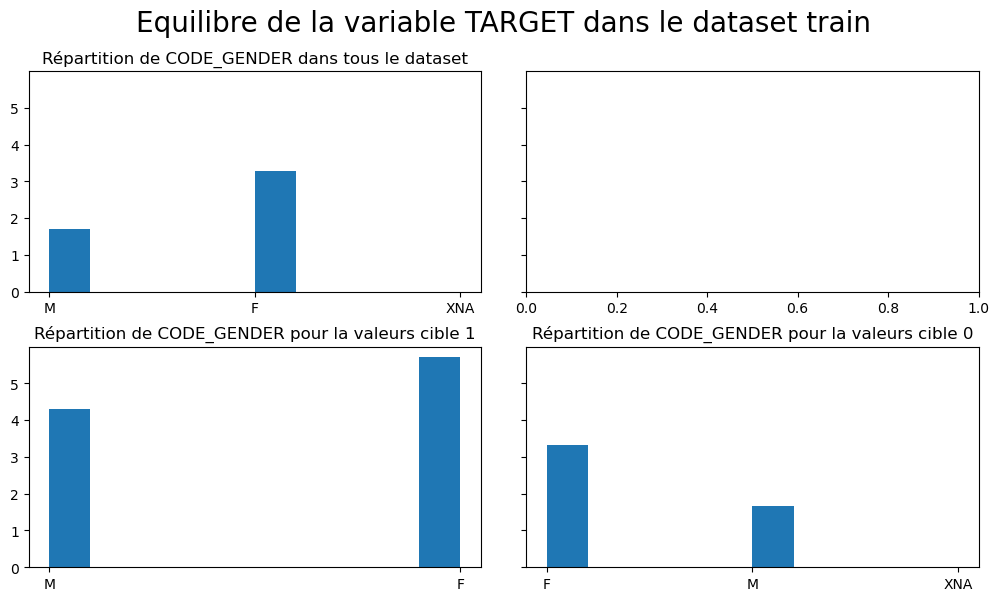

In [17]:
graph_desequilibre(train, "CODE_GENDER", "TARGET", "train")

On observe un déséquilibre pour la feature `CODE_GENDER`. La majorité des prêts on été contracter par des femme. Mais cette différence ce retrouve aussi dans les sous catégorie former par la valeurs la cible. Il est possible que notre modèle produissent de meilleur prévision si le client est une femme.

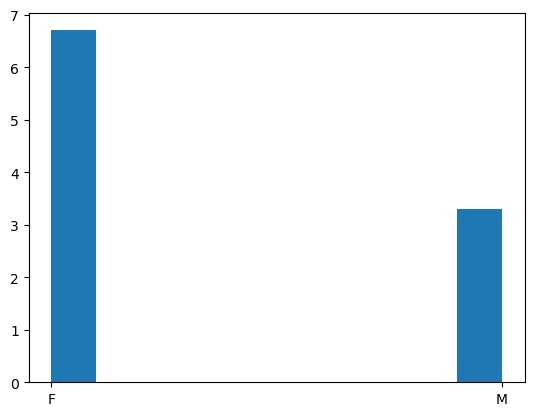

In [18]:
plt.hist(test["CODE_GENDER"], density=True)
plt.show()

Le même déséquilibre ce retrouve dans le dataset de test.

### Equilibe de `NAME_CONTRACT_TYPE`

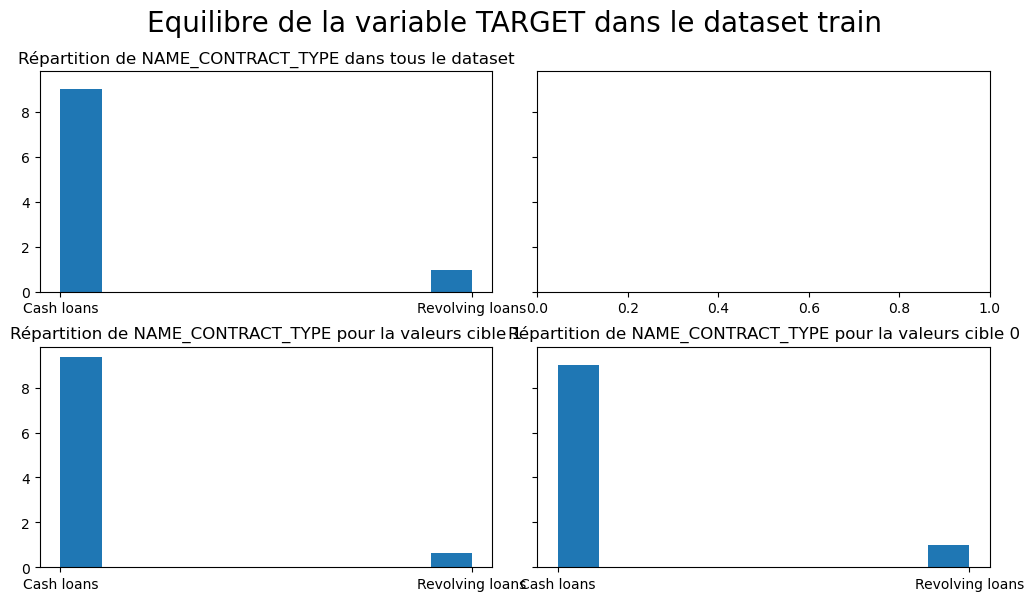

In [19]:
graph_desequilibre(train, 'NAME_CONTRACT_TYPE', "TARGET", "train")

La majorité des prêts contractés dans la base de données sont des prêts de type `Cash loans`. Ainsi on peut s'attendre a ce que le modèle ai des difficulté a prévoir correctement les remboursement pour des crédit de type `Revolving loans`.

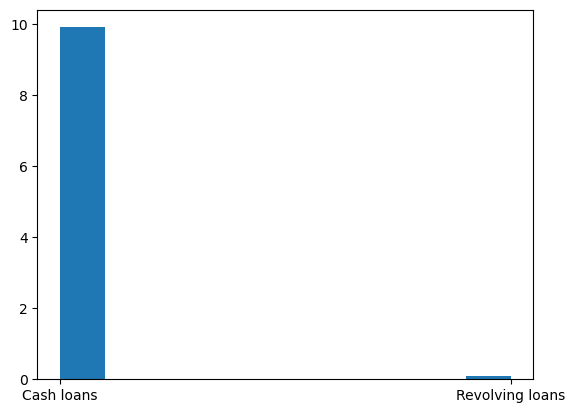

In [20]:
plt.hist(test["NAME_CONTRACT_TYPE"], density=True)
plt.show()

Ce déséquilibre est encore plus important dans le cas du dataset de test.

### Equilibre de `CNT_CHILDREN`

In [21]:
len(train["CNT_CHILDREN"].unique())

15

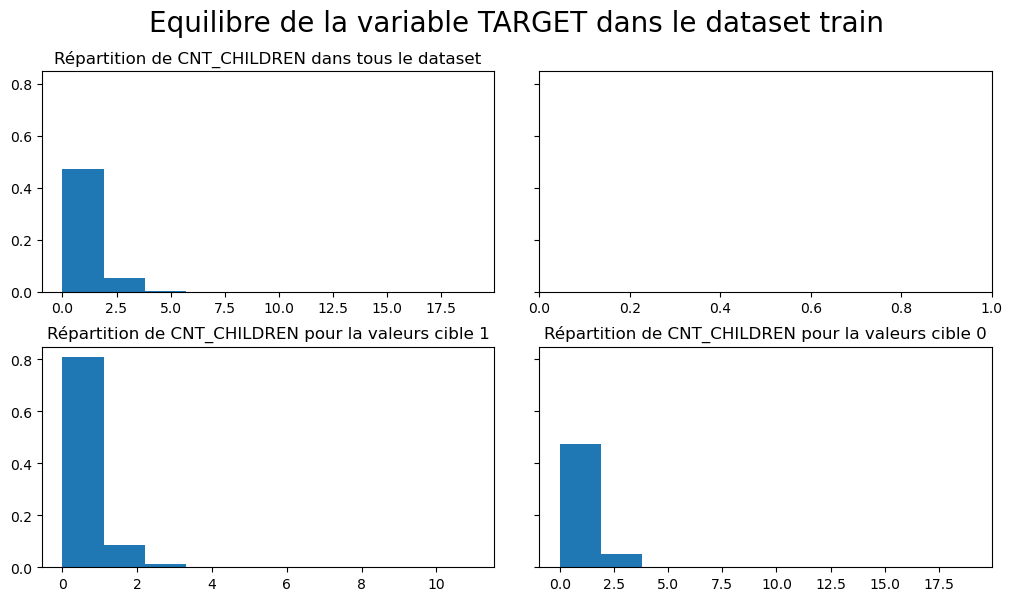

In [22]:
graph_desequilibre(train, "CNT_CHILDREN", "TARGET", "train")

La majoité des client ayant contracter un prêt on 0 ou 1 enfant. IL est trés rare qu'il en ai plus. Dans ce cas on a un déséquilibre qui pourrait être corriger en regroupant les vaelrus supérueyr à 2 dans une catégorie 3 enfant et plus.

## 3.4 Missing values 

La majorité des modèles ne fonctionne pas si les données utilisées pour leurs entraînement contiennent des données None.

In [23]:
# Function to calculate missing values by column# Funct 
def missing_values_table(df):
        # Total missing values
        mis_val = df.isNone().sum()
        
        # Percentage of missing values
        mis_val_percent = 100 * df.isNone().sum() / len(df)
        
        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
        
        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})
        
        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        
        # Print some summary information
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"      
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")
        
        # Return the dataframe with missing information
        return mis_val_table_ren_columns

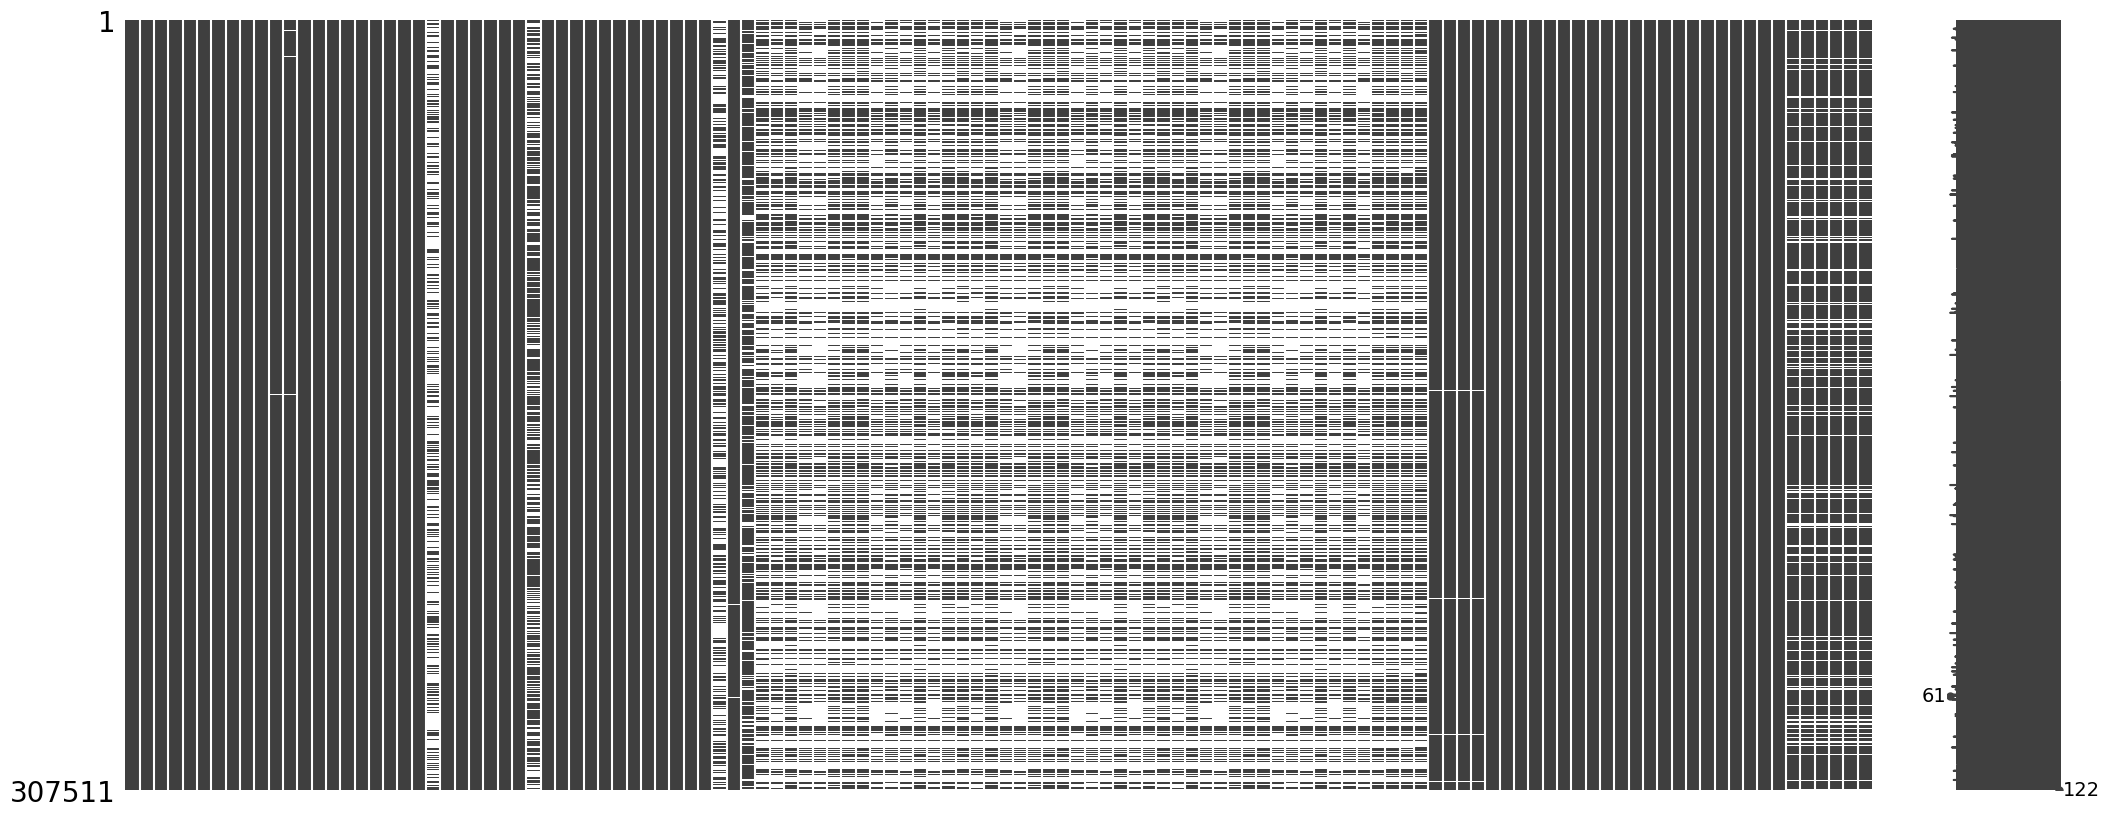

In [24]:
msno.matrix(train)
plt.show()

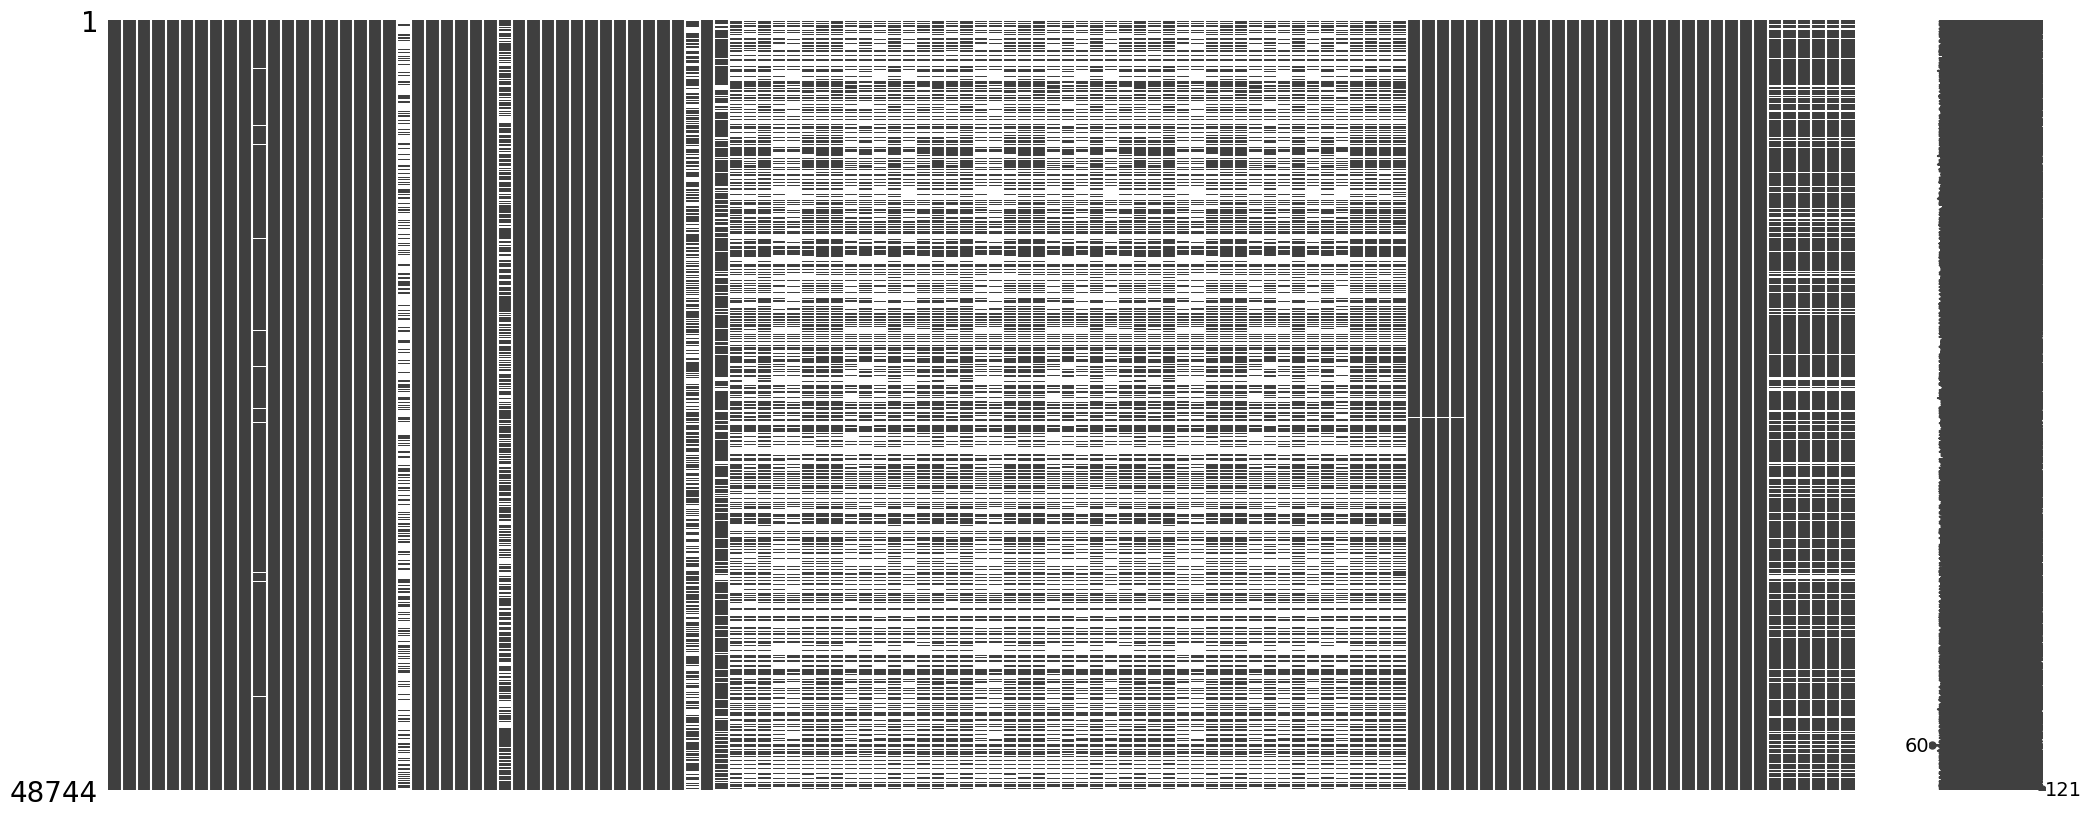

In [25]:
msno.matrix(test)
plt.show()

La majorité des colonnes avec des valeurs manquantes sont au centre du dataframe.

In [26]:
# Missing values statistics
missing_values = missing_values_table(train)
missing_values.head(60)

Your selected dataframe has 122 columns.
There are 67 columns that have missing values.


,Missing Values,% of Total Values
COMMONAREA_MEDI,214865,69.9
COMMONAREA_MODE,214865,69.9
COMMONAREA_AVG,214865,69.9
NONLIVINGAPARTMENTS_MODE,213514,69.4
NONLIVINGAPARTMENTS_MEDI,213514,69.4
NONLIVINGAPARTMENTS_AVG,213514,69.4
FONDKAPREMONT_MODE,210295,68.4
LIVINGAPARTMENTS_AVG,210199,68.4
LIVINGAPARTMENTS_MEDI,210199,68.4
LIVINGAPARTMENTS_MODE,210199,68.4


Une partie des colonnes correspondent à des features qui sont associées à d'autre comme des informations sur le bien posséder, la voiture. Etant donné que le client du prêt n'as pas de bien il est normale que ces valeurs soit vide. Pour ce features ci une imputation spécifique peut être utilisé.

## 3.5 Détaille des features qualitative

In [27]:
# Nombre de classe unique dans chacune des feature qualitatives
train.select_dtypes('object').apply(pd.Series.nunique, axis = 0)

NAME_CONTRACT_TYPE             2
CODE_GENDER                    3
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_TYPE_SUITE                7
NAME_INCOME_TYPE               8
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
OCCUPATION_TYPE               18
WEEKDAY_APPR_PROCESS_START     7
ORGANIZATION_TYPE             58
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
WALLSMATERIAL_MODE             7
EMERGENCYSTATE_MODE            2
dtype: int64

In [28]:
# Nombre de classe unique dans chacune des feature qualitatives
test.select_dtypes('object').apply(pd.Series.nunique, axis = 0)

NAME_CONTRACT_TYPE             2
CODE_GENDER                    2
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_TYPE_SUITE                7
NAME_INCOME_TYPE               7
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             5
NAME_HOUSING_TYPE              6
OCCUPATION_TYPE               18
WEEKDAY_APPR_PROCESS_START     7
ORGANIZATION_TYPE             58
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
WALLSMATERIAL_MODE             7
EMERGENCYSTATE_MODE            2
dtype: int64

In [29]:
# Nombre de classe unique dans chacune des feature qualitatives
temp1 = train.select_dtypes('object').apply(pd.Series.nunique, axis = 0)
temp1 = temp1.rename("train")

In [30]:
# Nombre de classe unique dans chacune des feature qualitatives
temp2 = test.select_dtypes('object').apply(pd.Series.nunique, axis = 0)
temp2 = temp2.rename("test")

In [31]:
temp = pd.concat([temp1, temp2], axis=1)

In [32]:
temp["diff"] = temp["train"] - temp["test"]

In [33]:
display(temp)

,train,test,diff
NAME_CONTRACT_TYPE,2,2,0
CODE_GENDER,3,2,1
FLAG_OWN_CAR,2,2,0
FLAG_OWN_REALTY,2,2,0
NAME_TYPE_SUITE,7,7,0
NAME_INCOME_TYPE,8,7,1
NAME_EDUCATION_TYPE,5,5,0
NAME_FAMILY_STATUS,6,5,1
NAME_HOUSING_TYPE,6,6,0
OCCUPATION_TYPE,18,18,0


On retrouve une catégorie supplémentaire pour `CODE_GENDER` dans le jeux de train, en fonction du nombre de ligne concerner on pourras simplement les supprimer.  
On trouve aussi une catégorie en plus pour `NAME_INCOME_TYPE` et `NAME_FAMILY_STATUS`

- `CODE_GENDER`

In [ ]:
train["CODE_GENDER"].value_counts()

On observe quatre ligne avec une valeurs de `CODE_GENDER` égale à XNA. C'est trés peux je vais les supprimer.

In [18]:
drop_index = train.loc[train["CODE_GENDER"] == "XNA"].index
train = train.drop(drop_index)
del drop_index

In [ ]:
train.shape

- `NAME_INCOME_TYPE`

In [37]:
train["NAME_INCOME_TYPE"].value_counts().sort_index()

NAME_INCOME_TYPE
Businessman                 10
Commercial associate     71616
Maternity leave              5
Pensioner                55362
State servant            21703
Student                     18
Unemployed                  22
Working                 158771
Name: count, dtype: int64

In [38]:
test["NAME_INCOME_TYPE"].value_counts().sort_index()

NAME_INCOME_TYPE
Businessman                 1
Commercial associate    11402
Pensioner                9273
State servant            3532
Student                     2
Unemployed                  1
Working                 24533
Name: count, dtype: int64

La catégorie supplémentaire et "maternity leave". Catégorie qui est représenté 5 fois dans le jeux de train. retiré ces itérations ?  
De plus on oberver un fort déséquilibre entre les différentes catégories de cette variable

- `NAME_FAMILY_STATUS`

In [39]:
train["NAME_FAMILY_STATUS"].value_counts().sort_index()

NAME_FAMILY_STATUS
Civil marriage           29774
Married                 196429
Separated                19770
Single / not married     45444
Unknown                      2
Widow                    16088
Name: count, dtype: int64

In [40]:
test["NAME_FAMILY_STATUS"].value_counts().sort_index()

NAME_FAMILY_STATUS
Civil marriage           4261
Married                 32283
Separated                2955
Single / not married     7036
Widow                    2209
Name: count, dtype: int64

La catégorie supplémentaire et "Unknown". Catégorie qui est représenté 2 fois dans le jeux de train. Je pense que je peut retiré cette catégorie.

In [41]:
drop_index = train.loc[train["NAME_FAMILY_STATUS"] == "Unknown"].index
train = train.drop(drop_index)
del drop_index

## 3.6 Anomalies

Il arrive que les features comportes des valeurs qui sont aberrante, c'est à dire qui sont clairement des erreur au regard de la features et des autres valeurs qui la compose. Je vais chercher à identifier ces anomalies dans les colonne de type float. Je ne vais pas pouvoir balayer les 64 feature et vais donc me concentré sur un sous ensemble.

### `DAYS_BIRTH`  
Ou Age de l'emprinteur au moment du prêt.  
Cette features est exprimées en jour depuis le début du prêt. Pour rendre interprétable cette feature, il faut les ramener en années en multipliant par -1 et en divisant par 365.

In [42]:
(train['DAYS_BIRTH'] / -365).describe()

count    307505.000000
mean         43.937122
std          11.956131
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: DAYS_BIRTH, dtype: float64

Il semble normale que les valeurs commence au alentour de 20ans, donc que seul des majeur ai contracter des prêts et que le client le plus agé ai 69 ans. Cette feature ne présente pas d'anomalies.

### `DAYS_EMPLOYED`  
Depuis combient de temps le client occupe sont emploie au moment du prêt.  
Comme pour la feature `DAYS_BIRTH` la valeurs de celle-ci est négative et exprimer en jour

In [7]:
train["DAYS_EMPLOYED"].head()

0    -637
1   -1188
2    -225
3   -3039
4   -3038
Name: DAYS_EMPLOYED, dtype: int64

In [8]:
(train["DAYS_EMPLOYED"]/-365).describe()

count    307511.000000
mean       -174.835742
std         387.056895
min       -1000.665753
25%           0.791781
50%           3.323288
75%           7.561644
max          49.073973
Name: DAYS_EMPLOYED, dtype: float64

La valeurs la plus petite est clairement erroné avec -1000 ans d'emploi. Le plus élever est au contraire cohérente.  
Je regarde plus en détaille.

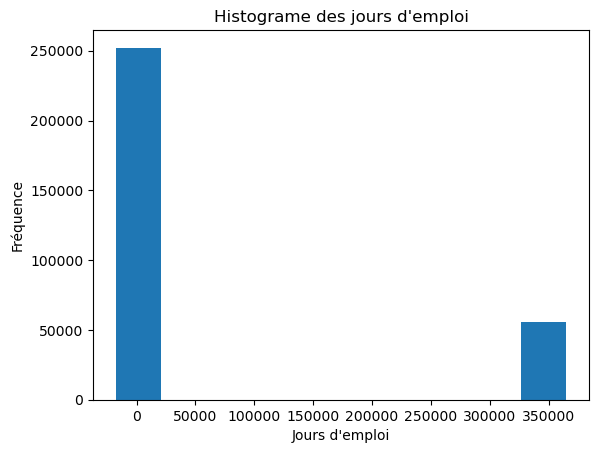

In [9]:
plt.hist(train["DAYS_EMPLOYED"])
plt.title("Histograme des jours d'emploi")
plt.xlabel("Jours d'emploi")
plt.ylabel("Fréquence")
plt.show()

In [10]:
train["DAYS_EMPLOYED"].value_counts().head()

DAYS_EMPLOYED
 365243    55374
-200         156
-224         152
-199         151
-230         151
Name: count, dtype: int64

Donc cette valeurs aberrante est partagé par 55374 personne. Il n'est donc pas envisageable de simplement supprimer ces lignes.  
Est-ce que la valeurs de `TARGET` est particuliers ?

In [11]:
anom = train[train['DAYS_EMPLOYED'] == 365243]
non_anom = train[train['DAYS_EMPLOYED'] != 365243]
print('Les points normaux présente un taux de défaut de remboursement de %0.2f%%' % (100 * non_anom['TARGET'].mean()))
print('Les points anormaux présente un taux de défaut de remboursement de %0.2f%%' % (100 * anom['TARGET'].mean()))

Les points normaux présente un taux de défaut de remboursement de 8.66%
Les points anormaux présente un taux de défaut de remboursement de 5.40%


Il semblerais que les points anormaux présente un taux de défaut plus faible que les autres. Donc cette valeurs semble être signifiante. On a donc envie de la remplacer avec une imputation tous en conservant l'information que les point était anormaux en créant une nouvelle colonne.

In [12]:
# creer la colonne de flag annomalie
train['DAYS_EMPLOYED_ANOM'] = 0
mask = train["DAYS_EMPLOYED"] == 365243
train.loc[mask, "DAYS_EMPLOYED_ANOM"] = 1
train.loc[mask, "DAYS_EMPLOYED"] = np.nan

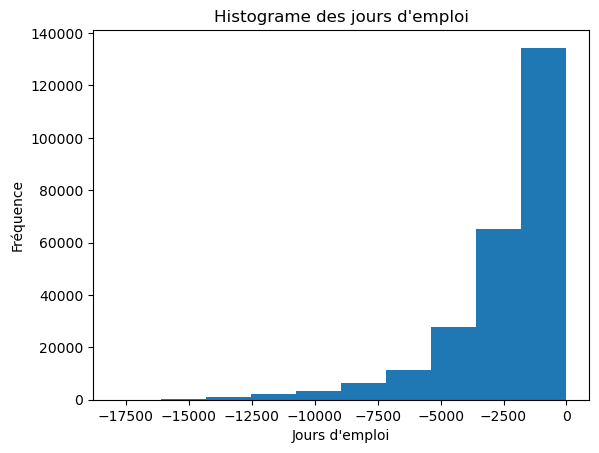

In [13]:
plt.hist(train["DAYS_EMPLOYED"])
plt.title("Histograme des jours d'emploi")
plt.xlabel("Jours d'emploi")
plt.ylabel("Fréquence")
plt.show()

La transformation a fonctionner

Il faut aussi faire cette transformation pour le set de test

In [14]:
test["DAYS_EMPLOYED"].value_counts().head()

DAYS_EMPLOYED
 365243    9274
-1119        32
-389         31
-1240        30
-148         28
Name: count, dtype: int64

In [15]:
anom = test[test['DAYS_EMPLOYED'] == 365243]
non_anom = test[test['DAYS_EMPLOYED'] != 365243]
print(f"Dans le jeu de test on trouve {non_anom.shape[0]} point normaux")
print(f"Dans le jeu de test on trouve {anom.shape[0]} point anormaux")

Dans le jeu de test on trouve 39470 point normaux
Dans le jeu de test on trouve 9274 point anormaux


In [16]:
# creer la colonne de flag annomalie
test['DAYS_EMPLOYED_ANOM'] = 0
mask = test["DAYS_EMPLOYED"] == 365243
test.loc[mask, "DAYS_EMPLOYED_ANOM"] = 1
test.loc[mask, "DAYS_EMPLOYED"] = np.nan

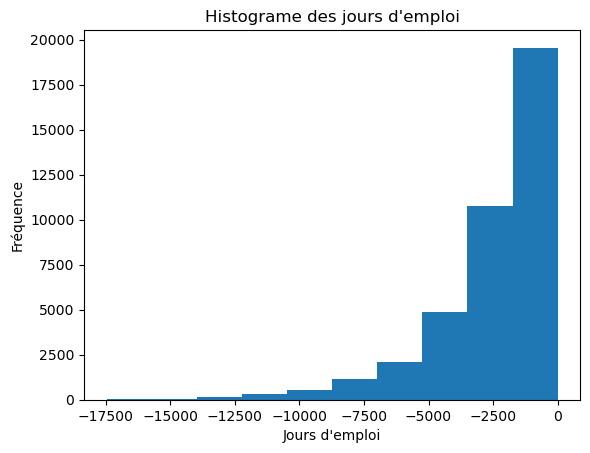

In [17]:
plt.hist(test["DAYS_EMPLOYED"])
plt.title("Histograme des jours d'emploi")
plt.xlabel("Jours d'emploi")
plt.ylabel("Fréquence")
plt.show()

# Encodage  
L'encodage des features ce fera dans le pipeline définit dans le notebook d'entraînement des modèles pour facilité le traitement. 

Encodage en one-hot encoder.  

Quand une feature qualitative ne contient que deux class on utilise le labelencoder
Sinon on utilse les autres type d'encodage poissibe, one-hot, Ordinal, Target.  

Faire une différence entre ces deux catégorie permet de limité le nombre de feature produite suite à l'encodage.  

Comment gérer les valeurs None de ces features ?

In [58]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder

- Encodage du dataframe train

In [51]:
# Initialisation des encodeurs
le = LabelEncoder()
one_h = OneHotEncoder(sparse_output=False)

# Copier le dataframe
df = copy.copy(train)

# Boucler sur les colonnes
## Identifier les colonnes a encoder
object_columns = df.select_dtypes("object").columns

## Déterminer le nombre de class dans chaque colonne et isoler celle avec strictement moins de 3 class
tow_class_columns = []
more_class_columns = []

for column in object_columns:
    n_class = len(
                df[column].unique()
                )
    
    if n_class < 3:
        tow_class_columns.append(column)
        
    elif n_class >= 2 :
        more_class_columns.append(column)

## Appliquer l'encodage
### Sur les feature a deux class
for column in tow_class_columns:
    df[column] = le.fit_transform(df[column])

### Sur les features avec plus de 2 class
encoded_more_class_columns = one_h.fit_transform(df.loc[:, more_class_columns])
### Constuire un dataframe avec la sortie
encoded_more_class_columns = pd.DataFrame(encoded_more_class_columns, columns=one_h.get_feature_names_out(), index=df.index)
### Ajouter ce dataframe à l'original
df = pd.concat([df, encoded_more_class_columns], axis=1)
### Supprimer les colonnes devenue inutile
df = df.drop(more_class_columns, axis=1)

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 307505 entries, 0 to 307510
Columns: 247 entries, SK_ID_CURR to EMERGENCYSTATE_MODE_nan
dtypes: float64(202), int64(45)
memory usage: 581.8 MB


In [53]:
encoded_train = copy.copy(df)

In [54]:
encoded_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 307505 entries, 0 to 307510
Columns: 247 entries, SK_ID_CURR to EMERGENCYSTATE_MODE_nan
dtypes: float64(202), int64(45)
memory usage: 581.8 MB


- Encodage du dataframe de test

In [55]:
del df

In [ ]:
# Initialisation des encodeurs
le = LabelEncoder()
one_h = OneHotEncoder(sparse_output=False)

# Copier le dataframe
df = copy.copy(test)

In [ ]:
# Boucler sur les colonnes
## Identifier les colonnes a encoder
object_columns = df.select_dtypes("object").columns

## Déterminer le nombre de class dans chaque colonne et isoler celle avec strictement moins de 3 class
tow_class_columns = []
more_class_columns = []

for column in object_columns:
    n_class = len(
                df[column].unique()
                )
    
    if n_class < 3:
        tow_class_columns.append(column)
        
    elif n_class >= 2 :
        more_class_columns.append(column)

In [56]:
## Appliquer l'encodage
### Sur les feature a deux class
for column in tow_class_columns:
    df[column] = le.fit_transform(df[column])

### Sur les features avec plus de 2 class
encoded_more_class_columns = one_h.fit_transform(df.loc[:, more_class_columns])
### Constuire un dataframe avec la sortie
encoded_more_class_columns = pd.DataFrame(encoded_more_class_columns, columns=one_h.get_feature_names_out(), index=df.index)
### Ajouter ce dataframe à l'original
df = pd.concat([df, encoded_more_class_columns], axis=1)
### Supprimer les colonnes devenue inutile
df = df.drop(more_class_columns, axis=1)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Columns: 245 entries, SK_ID_CURR to EMERGENCYSTATE_MODE_nan
dtypes: float64(201), int64(44)
memory usage: 91.1 MB


In [58]:
encoded_test = copy.copy(df)
del df

In [59]:
encoded_train.shape

(307505, 247)

In [60]:
encoded_test.shape

(48744, 245)

Le nombre de colonne n'est plus le même entre les deux dataframe. Pour réaliser la modélisation il faut qu'il soit identique.

In [61]:
train_labels = encoded_train['TARGET']

# Align the training and testing data, keep only columns present in both dataframes
encoded_train, encoded_test = encoded_train.align(encoded_test, join = 'inner', axis = 1)

# Add the target back in
encoded_train['TARGET'] = train_labels

print('Training Features shape: ', encoded_train.shape)
print('Testing Features shape: ', encoded_test.shape)

Training Features shape:  (307505, 246)
Testing Features shape:  (48744, 245)


Ce-fessant on retire une des class de certaine feature du dataframe.

Encodage en target encoder

# 4. Corrélation

Mesurer la corrélation entre les différentes features permet d'observer les relations entre les variables et la cible mais aussi entre les différentes variable.  
- Dans le cas de la corrélation avec la cible, de manière générale une feature très corréler seras souvent une feature très explicative de la cible.
- Dans le cas des variables entre elle, si celle-ci sont très corréler il peut être envisager de les combiner ou de leurs appliquer des transformation pour réduire la dimension du jeu de données. A l'inverse des variables très peut corréler entre elle sont très intéressante car elle apportent des informations différentes.

In [54]:
# Find correlations with the target and sort
correlations = encoded_train.corr()['TARGET'].sort_values()

NameError: name 'encoded_train' is not defined

In [ ]:
correlations = correlations.sort_values()

In [ ]:
correlations.head(15)

In [ ]:
correlations.tail(15)

Les features les plus corréler au la target sont :
- `EXT_SOURCE_3/2/1` en négatif.
- `DAYS_BIRTH` et `DAYS_IMPLOYED` en positif.

## Effet de l'âge sur remboursement des prêts

In [ ]:
encoded_train['DAYS_BIRTH'] = abs(encoded_train['DAYS_BIRTH'])
encoded_train['DAYS_BIRTH'].corr(encoded_train['TARGET'])

En ce basant sur ce coefficient de corrélation on peut dire que il a une relation inversement proportionnel entre le reboursement des prêt et l'âge. C'est a dire que les client les plus âgé on rembource un peut plus souvent leurs prêt que les plus jeune.

In [ ]:
# Set the style of plots
plt.style.use('fivethirtyeight')

# Plot the distribution of ages in years
plt.hist(encoded_train['DAYS_BIRTH'] / 365, edgecolor = 'k', bins = 50)
plt.title('Age des clients'); plt.xlabel('Age (années)'); plt.ylabel('Décompte');

Cette représentation ne nous apporte pas d'information quand à l'effet de l'âge sur le remboursement du prêt

In [ ]:
plt.figure(figsize = (10, 8))

# KDE plot of loans that were repaid on time
sns.kdeplot(encoded_train.loc[encoded_train['TARGET'] == 0, 'DAYS_BIRTH'] / 365, label = 'target == 0', color="Blue")

# KDE plot of loans which were not repaid on time
sns.kdeplot(encoded_train.loc[encoded_train['TARGET'] == 1, 'DAYS_BIRTH'] / 365, label = 'target == 1', color="red")

# Labeling of plot
plt.xlabel('Age (années)'); plt.ylabel('Densité'); plt.title('Distribution des âges');

On observe une sureprésentation des défaut de remboursement chez les jeunes (la courbe rouge est au dessus de la bleu), et l'inverse dans le cas des clients les plus âgés. L'âge semble bien avoir un effet sur notre variable cible.

On peut discrétiser la variable puis calculer le taux moyen de non rembourssemet par plage d'âge.v

In [ ]:
# Age information into a separate dataframe
age_data = encoded_train[['TARGET', 'DAYS_BIRTH']]
age_data['YEARS_BIRTH'] = age_data['DAYS_BIRTH'] / 365

# Bin the age data
age_data['YEARS_BINNED'] = pd.cut(age_data['YEARS_BIRTH'], bins = np.linspace(20, 70, num = 11))

# Group by the bin and calculate averages
age_groups  = age_data.groupby('YEARS_BINNED').mean()

In [ ]:
plt.figure(figsize = (8, 8))

# Graph the age bins and the average of the target as a bar plot
plt.bar(age_groups.index.astype(str), 100 * age_groups['TARGET'])

# Plot labeling
plt.xticks(rotation = 75); plt.xlabel("Groupe d'âge (années)"); plt.ylabel('Non-remboursement (%)')
plt.title("Non-remboursement par groupes d'âges");

On observe bien un taux de rembourssement plus faible chez 20 25 ans, et ce taux s'améliore alors que l'âge des clients augmente.

## Sources extérieur

Les trois variables présentant les corrélations négatives les plus fortes avec la variable cible sont `EXT_SOURCE_1`, `EXT_SOURCE_2` et `EXT_SOURCE_3`.

D'après la documentation, ces variables représentent un « score normalisé issu d'une source de données externe ». Je ne sais pas exactement ce que cela signifie, mais il pourrait s'agir d'une sorte de notation cumulative établie à partir de nombreuses sources de données.

Examinons ces variables.

Tout d'abord, nous pouvons afficher les corrélations des variables `EXT_SOURCE` avec la variable cible et entre elles.

In [ ]:
# Extraire les sources externes du dataframe puis calculer leurs corrélation entre elles la target et la variables DAYS_BIRTH
ext_data = encoded_train[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']]
ext_data_corrs = ext_data.corr()
ext_data_corrs

Les différentes sources externe sont corréler entre elle mais les coefficients reste faible. On remarque que la source externe 1 est très fortement corréler avec l'âge de clients.

In [ ]:
plt.figure(figsize = (10, 12))

# iterate through the sources
for i, source in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    
    # create a new subplot for each source
    plt.subplot(3, 1, i + 1)
    # plot repaid loans
    sns.kdeplot(encoded_train.loc[encoded_train['TARGET'] == 0, source], label = 'target == 0', color="blue")
    # plot loans that were not repaid
    sns.kdeplot(encoded_train.loc[encoded_train['TARGET'] == 1, source], label = 'target == 1', color="red")
    
    # Label the plots
    plt.title('Distribution of %s by Target Value' % source)
    plt.xlabel('%s' % source); plt.ylabel('Density');
    
plt.tight_layout(h_pad = 2.5)

Les sources externes on bien un effet sur la variables cible. globalement plus leurs valeurs est élevée plus les clients rembource leurs prêt.

In [ ]:
# Copy the data for plotting
plot_data = ext_data.drop(columns = ['DAYS_BIRTH']).copy()

# Add in the age of the client in years
plot_data['YEARS_BIRTH'] = age_data['YEARS_BIRTH']

# Drop na values and limit to first 100000 rows
plot_data = plot_data.dropna().loc[:100000, :]

# Function to calculate correlation coefficient between two columns
def corr_func(x, y, **kwargs):
    r = np.corrcoef(x, y)[0][1]
    ax = plt.gca()
    ax.annotate("r = {:.2f}".format(r),
                xy=(.2, .8), xycoords=ax.transAxes,
                size = 20)

# Create the pairgrid object
grid = sns.PairGrid(data = plot_data, 
                    #size = 3, 
                    diag_sharey=False,
                    hue = 'TARGET', 
                    vars = [x for x in list(plot_data.columns) if x != 'TARGET'])

# Upper is a scatter plot
grid.map_upper(plt.scatter, alpha = 0.2)

# Diagonal is a histogram
grid.map_diag(sns.kdeplot)

# Bottom is density plot
grid.map_lower(sns.kdeplot, cmap = plt.cm.OrRd_r);

plt.suptitle('Ext Source and Age Features Pairs Plot', size = 32, y = 1.05);

# 5. Feature engineering

Dans cette parti seul la feature génération sera étudier mais elle seras aussi encoder dans le pipeline de traitement pour facilité le déploiement.

In [362]:
# Make a new dataframe for polynomial features
poly_features = encoded_train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'TARGET']]
poly_features_test = encoded_test[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']]

# imputer for handling missing values
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy = 'median')

poly_target = poly_features['TARGET']

poly_features = poly_features.drop(columns = ['TARGET'])

# Need to impute missing values
poly_features = imputer.fit_transform(poly_features)
poly_features_test = imputer.transform(poly_features_test)

from sklearn.preprocessing import PolynomialFeatures
                                  
# Create the polynomial object with specified degree
poly_transformer = PolynomialFeatures(degree = 3)

In [363]:
# Train the polynomial features
poly_transformer.fit(poly_features)

# Transform the features
poly_features = poly_transformer.transform(poly_features)
poly_features_test = poly_transformer.transform(poly_features_test)
print('Polynomial Features shape: ', poly_features.shape)

Polynomial Features shape:  (307505, 35)


This creates a considerable number of new features. To get the names we have to use the polynomial features `get_feature_names` method.

In [364]:
poly_transformer.get_feature_names_out(input_features = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH'])[:15]

array(['1', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH',
       'EXT_SOURCE_1^2', 'EXT_SOURCE_1 EXT_SOURCE_2',
       'EXT_SOURCE_1 EXT_SOURCE_3', 'EXT_SOURCE_1 DAYS_BIRTH',
       'EXT_SOURCE_2^2', 'EXT_SOURCE_2 EXT_SOURCE_3',
       'EXT_SOURCE_2 DAYS_BIRTH', 'EXT_SOURCE_3^2',
       'EXT_SOURCE_3 DAYS_BIRTH', 'DAYS_BIRTH^2'], dtype=object)

There are 35 features with individual features raised to powers up to degree 3 and interaction terms. Now, we can see whether any of these new features are correlated with the target.

In [365]:
# Create a dataframe of the features 
poly_features = pd.DataFrame(poly_features, 
                             columns = poly_transformer.get_feature_names_out(['EXT_SOURCE_1', 'EXT_SOURCE_2', 
                                                                           'EXT_SOURCE_3', 'DAYS_BIRTH']))

# Add in the target
poly_features['TARGET'] = poly_target

# Find the correlations with the target
poly_corrs = poly_features.corr()['TARGET'].sort_values()

# Display most negative and most positive
print(poly_corrs.head(10))
print(poly_corrs.tail(5))

EXT_SOURCE_2 EXT_SOURCE_3                -0.023984
EXT_SOURCE_2 EXT_SOURCE_3 DAYS_BIRTH     -0.023865
EXT_SOURCE_1 EXT_SOURCE_2 EXT_SOURCE_3   -0.023852
EXT_SOURCE_2^2 EXT_SOURCE_3              -0.022139
EXT_SOURCE_2 EXT_SOURCE_3^2              -0.021583
EXT_SOURCE_2 DAYS_BIRTH                  -0.021346
EXT_SOURCE_1 EXT_SOURCE_2                -0.020694
EXT_SOURCE_1 EXT_SOURCE_2 DAYS_BIRTH     -0.020597
EXT_SOURCE_2^2 DAYS_BIRTH                -0.020374
EXT_SOURCE_2                             -0.020145
Name: TARGET, dtype: float64
EXT_SOURCE_1^2   -0.011014
DAYS_BIRTH^3     -0.010862
EXT_SOURCE_1^3   -0.010109
TARGET            1.000000
1                      NaN
Name: TARGET, dtype: float64


Several of the new variables have a greater (in terms of absolute magnitude) correlation with the target than the original features. When we build machine learning models, we can try with and without these features to determine if they actually help the model learn. 

We will add these features to a copy of the training and testing data and then evaluate models with and without the features. Many times in machine learning, the only way to know if an approach will work is to try it out! 

In [366]:
# Put test features into dataframe
poly_features_test = pd.DataFrame(poly_features_test, 
                                  columns = poly_transformer.get_feature_names_out(['EXT_SOURCE_1', 'EXT_SOURCE_2', 
                                                                                'EXT_SOURCE_3', 'DAYS_BIRTH']))

# Merge polynomial features into training dataframe
poly_features['SK_ID_CURR'] = encoded_train['SK_ID_CURR']
encoded_train_poly = encoded_train.merge(poly_features, on = 'SK_ID_CURR', how = 'left')

# Merge polnomial features into testing dataframe
poly_features_test['SK_ID_CURR'] = encoded_test['SK_ID_CURR']
encoded_test_poly = encoded_test.merge(poly_features_test, on = 'SK_ID_CURR', how = 'left')

# Align the dataframes
encoded_train_poly, encoded_test_poly = encoded_train_poly.align(encoded_test_poly, join = 'inner', axis = 1)

# Print out the new shapes
print('Training data with polynomial features shape: ', encoded_train_poly.shape)
print('Testing data with polynomial features shape:  ', encoded_test_poly.shape)

Training data with polynomial features shape:  (307505, 280)
Testing data with polynomial features shape:   (48744, 280)


## Domain Knowledge Features

Maybe it's not entirely correct to call this "domain knowledge" because I'm not a credit expert, but perhaps we could call this "attempts at applying limited financial knowledge". In this frame of mind, we can make a couple features that attempt to capture what we think may be important for telling whether a client will default on a loan. Here I'm going to use five features that were inspired by [this script](https://www.kaggle.com/jsaguiar/updated-0-792-lb-lightgbm-with-simple-features) by Aguiar:

* `CREDIT_INCOME_PERCENT`: the percentage of the credit amount relative to a client's income
* `ANNUITY_INCOME_PERCENT`: the percentage of the loan annuity relative to a client's income
* `CREDIT_TERM`:  the length of the payment in months (since the annuity is the monthly amount due
* `DAYS_EMPLOYED_PERCENT`: the percentage of the days employed relative to the client's age

Again, thanks to Aguiar and [his great script](https://www.kaggle.com/jsaguiar/updated-0-792-lb-lightgbm-with-simple-features) for exploring these features.



In [367]:
encoded_train_domain = encoded_train.copy()
encoded_test_domain = encoded_test.copy()

encoded_train_domain['CREDIT_INCOME_PERCENT'] = encoded_train_domain['AMT_CREDIT'] / encoded_train_domain['AMT_INCOME_TOTAL']
encoded_train_domain['ANNUITY_INCOME_PERCENT'] = encoded_train_domain['AMT_ANNUITY'] / encoded_train_domain['AMT_INCOME_TOTAL']
encoded_train_domain['CREDIT_TERM'] = encoded_train_domain['AMT_ANNUITY'] / encoded_train_domain['AMT_CREDIT']
encoded_train_domain['DAYS_EMPLOYED_PERCENT'] = encoded_train_domain['DAYS_EMPLOYED'] / encoded_train_domain['DAYS_BIRTH']

In [368]:
encoded_test_domain['CREDIT_INCOME_PERCENT'] = encoded_test_domain['AMT_CREDIT'] / encoded_test_domain['AMT_INCOME_TOTAL']
encoded_test_domain['ANNUITY_INCOME_PERCENT'] = encoded_test_domain['AMT_ANNUITY'] / encoded_test_domain['AMT_INCOME_TOTAL']
encoded_test_domain['CREDIT_TERM'] = encoded_test_domain['AMT_ANNUITY'] / encoded_test_domain['AMT_CREDIT']
encoded_test_domain['DAYS_EMPLOYED_PERCENT'] = encoded_test_domain['DAYS_EMPLOYED'] / encoded_test_domain['DAYS_BIRTH']

#### Visualize New Variables

We should explore these __domain knowledge__ variables visually in a graph. For all of these, we will make the same KDE plot colored by the value of the `TARGET`.

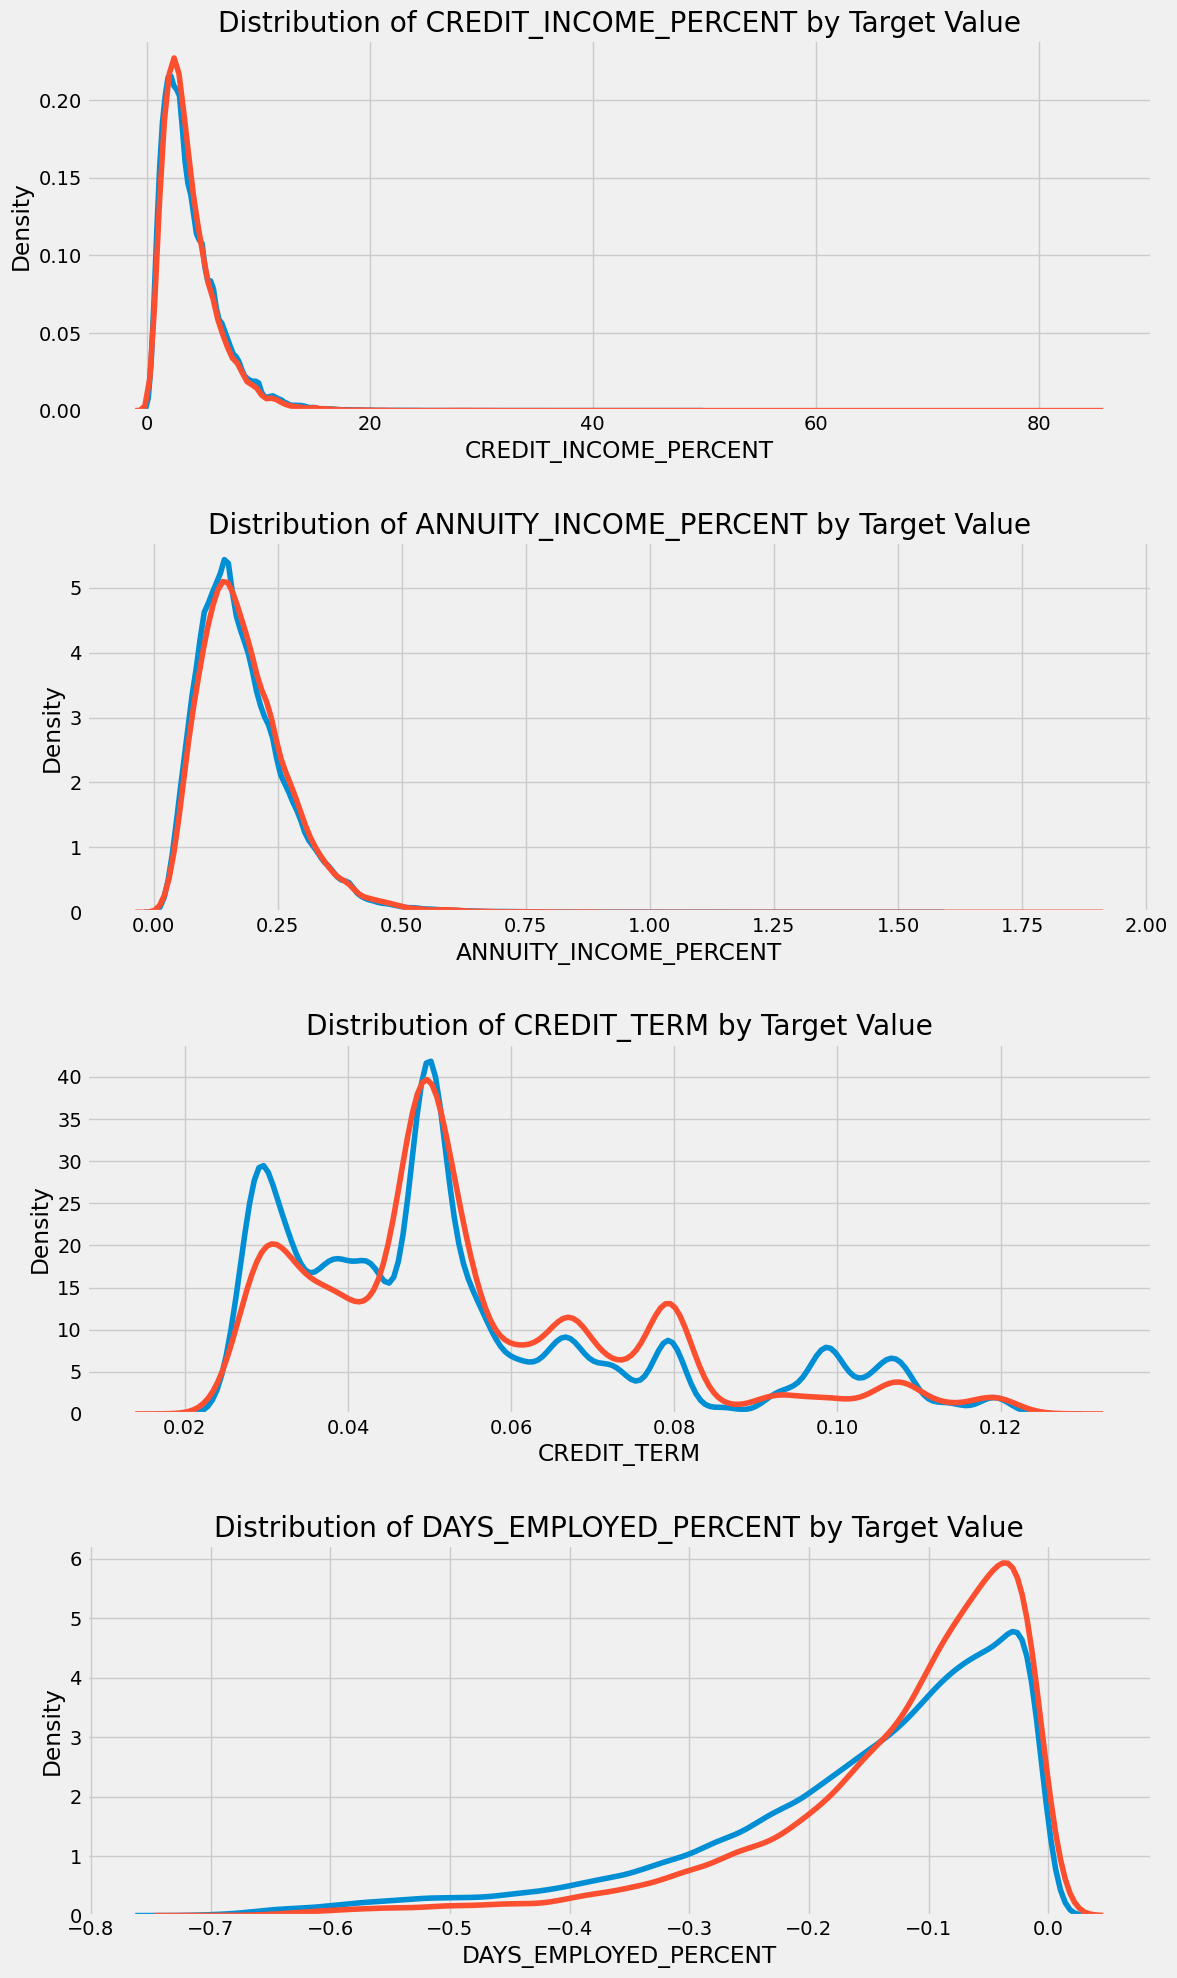

In [369]:
plt.figure(figsize = (12, 20))
# iterate through the new features
for i, feature in enumerate(['CREDIT_INCOME_PERCENT', 'ANNUITY_INCOME_PERCENT', 'CREDIT_TERM', 'DAYS_EMPLOYED_PERCENT']):
    
    # create a new subplot for each source
    plt.subplot(4, 1, i + 1)
    # plot repaid loans
    sns.kdeplot(encoded_train_domain.loc[encoded_train_domain['TARGET'] == 0, feature], label = 'target == 0')
    # plot loans that were not repaid
    sns.kdeplot(encoded_train_domain.loc[encoded_train_domain['TARGET'] == 1, feature], label = 'target == 1')
    
    # Label the plots
    plt.title('Distribution of %s by Target Value' % feature)
    plt.xlabel('%s' % feature); plt.ylabel('Density');
    
plt.tight_layout(h_pad = 2.5)

# 6. Modélisation rapide

## Définition du pipeline

In [19]:
from sklearn.pipeline import Pipeline

In [20]:
from sklearn.compose import ColumnTransformer

In [21]:
from sklearn.linear_model import LogisticRegression

In [22]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder

In [23]:
# Copier le dataframe
df = copy.copy(train)

# Boucler sur les colonnes
## Identifier les colonnes a encoder
object_columns = df.select_dtypes("object").columns

## Déterminer le nombre de class dans chaque colonne et isoler celle avec strictement moins de 3 class
tow_class_columns = []
more_class_columns = []

for column in object_columns:
    n_class = len(
                df[column].unique()
                )
    
    if n_class < 3:
        tow_class_columns.append(column)
        
    elif n_class >= 2 :
        more_class_columns.append(column)

In [24]:
transformer = ColumnTransformer([ # Encodage des variables type object 
              ("Ordi_encoder", OrdinalEncoder(), tow_class_columns),
              ("one-hot_encoder", OneHotEncoder(sparse_output=False), more_class_columns)
                ])

pipe = Pipeline([
              #("json_imputer", SimpleImputer(strategy = "constant", missing_values=None, fill_value=np.nan)),
              ("transformer", transformer),
              ("imputer", SimpleImputer(strategy = "median", missing_values = float("nan"))),
              ("Scaler", MinMaxScaler()),
              ("Classifier", LogisticRegression(C = 0.0001))
                ])

In [25]:
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('transformer', ...), ('imputer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Ordi_encoder', ...), ('one-hot_encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of th

## Développement de la métric

In [77]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [86]:
train_labels

0         1
1         0
2         0
3         0
4         0
         ..
307506    0
307507    0
307508    0
307509    1
307510    0
Name: TARGET, Length: 307505, dtype: int64

### Seuil de 0,5

- Construction du labels prévue en fonction d'un seuil de probabilité (P(1))

In [146]:
submit["pred_labels"] = submit["TARGET"]
threshold = 0.5
mask = submit["TARGET"] < threshold

submit.loc[mask, "pred_labels"] = 0
submit.loc[~mask, "pred_labels"] = 1 # Si la probabilité de ne pas rembourser le crédit et supérieur au seuil le client ne remboursera pas, le crédit est refuser

C:\Users\SUZON\AppData\Local\Temp\ipykernel_10628\1954790308.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  submit["pred_labels"] = submit["TARGET"]


- Test avec la Confusion matrix

In [147]:
conf_m = confusion_matrix(train_labels, submit["pred_labels"])

In [148]:
conf_m

array([[282680,      0],
       [ 24825,      0]])

$\begin{bmatrix}VP &FN \\ FP & VN \end{bmatrix}$

In [149]:
conf_m[0,1] #FN

np.int64(0)

In [150]:
conf_m[1,0] #FP

np.int64(24825)

In [151]:
score = conf_m[0,1] + 10*conf_m[1,0]
score

np.int64(248250)

In [152]:
score = 10*conf_m[0,1] + conf_m[1,0]
score

np.int64(24825)

- Test avec la ConfusionMatrixDisplay

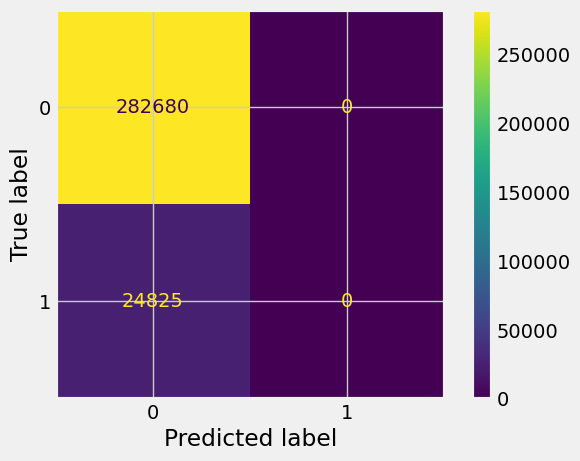

In [153]:
ConfusionMatrixDisplay.from_predictions(train_labels, submit["pred_labels"])
plt.show()

Le modèle actuel aevc un seuil de 0.5 est incapable de détéctée les clients sucéptible de ne pas rembourser.

### Seuil de 0,1

- Construction du labels prévue en fonction d'un seuil de probabilité (P(1))

In [154]:
submit["pred_labels"] = submit["TARGET"]
threshold = 0.1
mask = submit["TARGET"] < threshold

submit.loc[mask, "pred_labels"] = 0
submit.loc[~mask, "pred_labels"] = 1 # Si la probabilité de ne pas rembourser le crédit et supérieur au seuil le client ne remboursera pas, le crédit est refuser

C:\Users\SUZON\AppData\Local\Temp\ipykernel_10628\2919658367.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  submit["pred_labels"] = submit["TARGET"]


- Test avec la Confusion matrix

In [155]:
conf_m = confusion_matrix(train_labels, submit["pred_labels"])

In [156]:
conf_m

array([[236339,  46341],
       [ 15020,   9805]])

$\begin{bmatrix}VP &FN \\ FP & VN \end{bmatrix}$

In [157]:
conf_m[0,1] #FN

np.int64(46341)

In [158]:
conf_m[1,0] #FP

np.int64(15020)

In [159]:
score = conf_m[0,1] + 10*conf_m[1,0]
score

np.int64(196541)

In [160]:
score = 10*conf_m[0,1] + conf_m[1,0]
score

np.int64(478430)

- Test avec la ConfusionMatrixDisplay

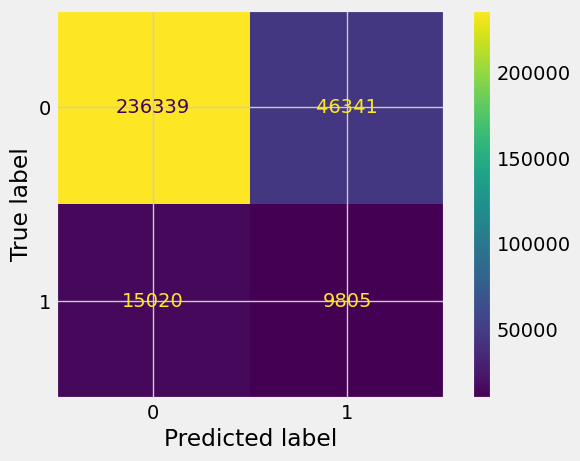

In [161]:
ConfusionMatrixDisplay.from_predictions(train_labels, submit["pred_labels"])
plt.show()

### Seuil de 0,05

- Construction du labels prévue en fonction d'un seuil de probabilité (P(1))

In [162]:
submit["pred_labels"] = submit["TARGET"]
threshold = 0.05
mask = submit["TARGET"] < threshold

submit.loc[mask, "pred_labels"] = 0
submit.loc[~mask, "pred_labels"] = 1 # Si la probabilité de ne pas rembourser le crédit et supérieur au seuil le client ne remboursera pas, le crédit est refuser

C:\Users\SUZON\AppData\Local\Temp\ipykernel_10628\776031445.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  submit["pred_labels"] = submit["TARGET"]


- Test avec la Confusion matrix

In [163]:
conf_m = confusion_matrix(train_labels, submit["pred_labels"])

In [164]:
conf_m

array([[ 13834, 268846],
       [   300,  24525]])

$\begin{bmatrix}VP &FN \\ FP & VN \end{bmatrix}$

In [165]:
conf_m[0,1] #FN

np.int64(268846)

In [166]:
conf_m[1,0] #FP

np.int64(300)

In [167]:
score = conf_m[0,1] + 10*conf_m[1,0]
score

np.int64(271846)

In [168]:
score = 10*conf_m[0,1] + conf_m[1,0]
score

np.int64(2688760)

- Test avec la ConfusionMatrixDisplay

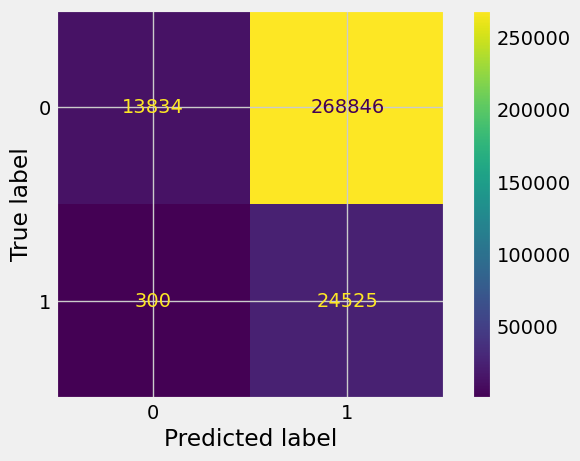

In [169]:
ConfusionMatrixDisplay.from_predictions(train_labels, submit["pred_labels"])
plt.show()

### Graphique évolution du nombre de faux positif

In [214]:
results = []
for threshold in [n/1000 for n in range(5,200 ,5)]:
    
    # Affectation des classe en fonction du seuil
    submit.loc[:, "pred_labels"] = submit.loc[:, "TARGET"]
    mask = submit["TARGET"] < threshold

    submit.loc[mask, "pred_labels"] = 0
    submit.loc[~mask, "pred_labels"] = 1 # Si la probabilité de ne pas rembourser le crédit et supérieur au seuil le client ne remboursera pas, le crédit est refuser

    # Calcul le la matrice de confusion.
    conf_m = confusion_matrix(train_labels, submit["pred_labels"])

    # [VP, VN, FN, FP]
    results.append(np.array([threshold, conf_m[0,0], conf_m[1,1], conf_m[0,1], conf_m[1,0]]))

- Construction du dataframe de résultats

In [218]:
df_threshold = pd.DataFrame(results, columns=[["threshold","VP", "VN", "FN", "FP"]])

- Calcul des scores possibles

In [238]:
df_threshold.loc[:, "1*FN + 10*FP"] = 1*df_threshold["FN"].values + 10*df_threshold["FP"].values
df_threshold.loc[:, "10*FN + 1*FP"] = 10*df_threshold["FN"].values + 1*df_threshold["FP"].values

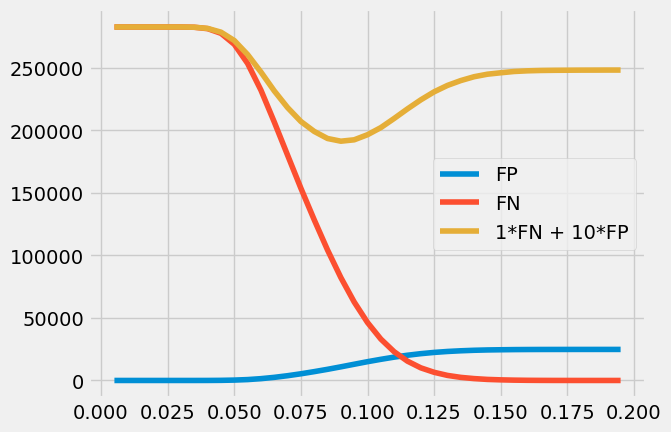

In [239]:
plt.plot(df_threshold["threshold"], df_threshold["FP"], label="FP")
plt.plot(df_threshold["threshold"], df_threshold["FN"], label="FN")

plt.plot(df_threshold["threshold"], df_threshold["1*FN + 10*FP"], label="1*FN + 10*FP")
#plt.plot(df_threshold["threshold"], df_threshold["10*FN + 1*FP"], label="10*FN + 1*FP")

plt.legend()
plt.show()

In [417]:
df_threshold["1*FN + 10*FP"].min()

1*FN + 10*FP    191360.0
dtype: float64

In [420]:
df_threshold.loc[17,:]

threshold            0.09
VP              200410.00
VN               13916.00
FN               82270.00
FP               10909.00
1*FN + 10*FP    191360.00
10*FN + 1*FP    833609.00
Name: 17, dtype: float64

### Score Code IA

In [26]:
from sklearn.metrics import confusion_matrix, make_scorer

In [27]:
def my_metric(y_true, y_pred_proba, threshold):
    
    # Formate en un dataframe pour facilité les calculs
    y_true.reset_index(drop=True, inplace=True)
    pred_serie = pd.Series(y_pred_proba, name="pred")
    true_label_serie = pd.Series(y_true, name="true_label")
    df = pd.concat([pred_serie, true_label_serie], axis=1)
    
    # Affectation à une classe en fonction du seuil
    ## Construire une nouvelle colonne
    df.loc[:, "pred_label"] = (df["pred"] >= threshold).astype(int)
    
    # Calcul du score metric
    conf_m = confusion_matrix(df["true_label"], df["pred_label"])
    FN = conf_m[1, 0]
    FP = conf_m[0, 1]
    metric = FN + 10 * FP
    return -metric

# Définir le scorer avec les paramètres supplémentaires
threshold = 0.09
my_scorer = make_scorer(my_metric, response_method="predict_proba", threshold=threshold)


# Test pipeline

In [28]:
X = train[train.columns[2:]]
y = train["TARGET"]

In [29]:
X.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 307507 entries, 0 to 307510
Data columns (total 121 columns):
 #    Column                        Non-Null Count   Dtype  
---   ------                        --------------   -----  
 0    NAME_CONTRACT_TYPE            307507 non-null  object 
 1    CODE_GENDER                   307507 non-null  object 
 2    FLAG_OWN_CAR                  307507 non-null  object 
 3    FLAG_OWN_REALTY               307507 non-null  object 
 4    CNT_CHILDREN                  307507 non-null  int64  
 5    AMT_INCOME_TOTAL              307507 non-null  float64
 6    AMT_CREDIT                    307507 non-null  float64
 7    AMT_ANNUITY                   307495 non-null  float64
 8    AMT_GOODS_PRICE               307229 non-null  float64
 9    NAME_TYPE_SUITE               306215 non-null  object 
 10   NAME_INCOME_TYPE              307507 non-null  object 
 11   NAME_EDUCATION_TYPE           307507 non-null  object 
 12   NAME_FAMILY_STATUS            307

In [30]:
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('transformer', ...), ('imputer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Ordi_encoder', ...), ('one-hot_encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of th

In [31]:
# Définir les paramètres du GridSearch
param_grid = {'Classifier__C': [0.1, 1, 10]}

# Définir la GridSearch avec le scorer
grid_search = GridSearchCV(pipe, param_grid, scoring=my_scorer, n_jobs=14, error_score='raise')

# Effectuer la recherche
grid_search.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...n(C=0.0001))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'Classifier__C': [0.1, 1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(m...hreshold=0.09)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",14
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >

In [32]:
# Seuil 0.9 réentrainement sans rien changer
grid_search.best_score_

np.float64(-186461.6)

In [88]:
# Seuil de 0.9
grid_search.best_score_

np.float64(-186580.8)

In [89]:
# Seuil de  0.8
grid_search.best_score_

np.float64(-186580.8)

In [35]:
best_model = grid_search.best_estimator_

In [36]:
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('transformer', ...), ('imputer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Ordi_encoder', ...), ('one-hot_encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of th

In [92]:
y_pred = best_model.predict_proba(X)
y_pred

array([[0.82929401, 0.17070599],
       [0.96760248, 0.03239752],
       [0.91887427, 0.08112573],
       ...,
       [0.95710246, 0.04289754],
       [0.92687778, 0.07312222],
       [0.95055351, 0.04944649]], shape=(307505, 2))

In [93]:
y_pred = y_pred[:,1]
y_pred

array([0.17070599, 0.03239752, 0.08112573, ..., 0.04289754, 0.07312222,
       0.04944649], shape=(307505,))

In [94]:
y_pred = pd.Series(y_pred, name="y_pred")

In [95]:
pred_df = pd.concat([y.reset_index(drop=True), y_pred], axis=1)

In [96]:
pred_df.loc[:, "pred_label"] = (pred_df["y_pred"] >= threshold).astype(int)

In [97]:
pred_df.head()

,TARGET,y_pred,pred_label
0,1,0.170706,1
1,0,0.032398,0
2,0,0.081126,0
3,0,0.145883,1
4,0,0.149488,1


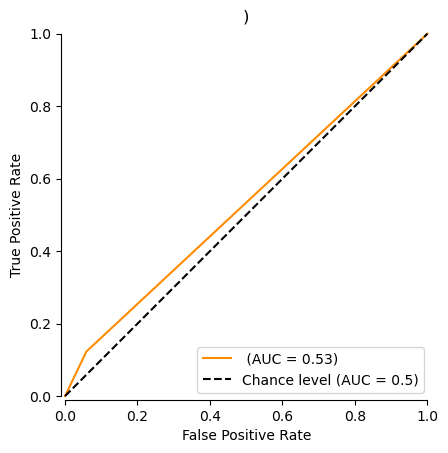

In [98]:
from sklearn.metrics import roc_curve
from sklearn.metrics import RocCurveDisplay

display = RocCurveDisplay.from_predictions(
    pred_df["pred_label"],
    pred_df["TARGET"],
    name=f"",
    curve_kwargs=dict(color="darkorange"),
    plot_chance_level=True,
    despine=True,
)
_ = display.ax_.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title=")",
)

# 7. Exportation du model format mlflow

Signature d'un modèle

Afin de garantir que les données d'entrée d'un modèle sont conformes à ce qui est attendu, les modèles MLflow peuvent inclure des metadatas décrivant les entrées et sorties :
- Model Signature - description des entrées et sorties du modèle
- Model Input Example - exemple d'une entrée valide

La signature du modèle permet de renseigner le nom des colonnes et leurs types afin de vérifier si ils sont similaires lors de la prédiction.

[Documentation, exemple signature](https://mlflow.org/docs/latest/ml/model/signatures/)

In [38]:
from mlflow.models.signature import infer_signature

In [39]:
signature = infer_signature(X, y)

D:\Users\SUZON\AppData\Local\anaconda3\envs\ml_flow_python_3_13_7\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


## Sauvegarde du modèle sklearn

In [40]:
import mlflow.sklearn

In [41]:
mlflow.sklearn.save_model(best_model, "./data/modeles/mlflow_LogisiticRegression_proba", signature=signature, pyfunc_predict_fn="predict_proba")

## Initialiser l'API

In [105]:
ls

 Le volume dans le lecteur C s’appelle Windows
 Le numéro de série du volume est 6EE8-06AD

 Répertoire de C:\Users\SUZON\OneDrive - CNR\Documents\Jupyter\Openclassrooms\Projets Openclassrooms\Projet-7-Implementez-un-modele-de-scoring

15/12/2025  13:50    <DIR>          .
27/11/2025  13:52    <DIR>          ..
05/12/2025  13:45    <DIR>          .ipynb_checkpoints
15/12/2025  12:12    <DIR>          data
15/12/2025  10:45            53 478 entrainement_des_model.ipynb
27/11/2025  15:40    <DIR>          mlruns
15/12/2025  13:50         1 525 826 preparation_des_données.ipynb
05/12/2025  13:45         1 754 221 preparation_des_données-Copy1.ipynb
27/11/2025  11:34               644 set_launch_mlflow_server.py
27/11/2025  10:45             2 368 set_mlflow_tracking.py
               5 fichier(s)        3 336 537 octets
               5 Rép(s)  332 030 849 024 octets libres


In [ ]:
# Dans le terminal conda, dans le dossier qui contient le pojet
mlflow models serve -m ./data/modeles/mlflow_LogisiticRegression

In [ ]:
# Dans le terminal conda, dans le dossier qui contient le pojet
mlflow models serve -m ./data/modeles/mlflow_LogisiticRegression_proba

## Requêter le serveur

### erreur

In [18]:
import requests

In [90]:
def request_prediction(model_uri, data, data_type):
    headers = {"Content-Type": "application/json"}

    data_json = {f"{data_type}": data}
    response = requests.request(
        method='POST', headers=headers, url=model_uri, json=data_json)

    if response.status_code != 200:
        raise Exception(
            "Request failed with status {}, {}".format(response.status_code, response.text))

    return response.json()

In [20]:
line_test = test.iloc[11, 1:]
line_test

NAME_CONTRACT_TYPE            Cash loans
CODE_GENDER                            F
FLAG_OWN_CAR                           N
FLAG_OWN_REALTY                        Y
CNT_CHILDREN                           0
                                 ...    
AMT_REQ_CREDIT_BUREAU_WEEK           0.0
AMT_REQ_CREDIT_BUREAU_MON            0.0
AMT_REQ_CREDIT_BUREAU_QRT            0.0
AMT_REQ_CREDIT_BUREAU_YEAR           5.0
DAYS_EMPLOYED_ANOM                     0
Name: 11, Length: 121, dtype: object

Call la signature du model

In [21]:
from mlflow import pyfunc

In [22]:
# Chargez le modèle
loaded_model = pyfunc.load_model("./data/modeles/mlflow_LogisiticRegression")

# Voir la signature
model_signature = loaded_model.metadata.signature

2025/12/17 16:22:12 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/12/17 16:22:12 INFO mlflow.store.db.utils: Updating database tables
2025/12/17 16:22:12 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2025/12/17 16:22:12 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2025/12/17 16:22:12 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2025/12/17 16:22:12 INFO alembic.runtime.migration: Will assume non-transactional DDL.


In [ ]:
model_signature

In [23]:
import json

In [43]:
formatted_json = test.iloc[11, 1:].to_json(orient="split")
json_instance = json.loads(formatted_json)

In [44]:
json_instance

{'name': 11,
 'index': ['NAME_CONTRACT_TYPE',
  'CODE_GENDER',
  'FLAG_OWN_CAR',
  'FLAG_OWN_REALTY',
  'CNT_CHILDREN',
  'AMT_INCOME_TOTAL',
  'AMT_CREDIT',
  'AMT_ANNUITY',
  'AMT_GOODS_PRICE',
  'NAME_TYPE_SUITE',
  'NAME_INCOME_TYPE',
  'NAME_EDUCATION_TYPE',
  'NAME_FAMILY_STATUS',
  'NAME_HOUSING_TYPE',
  'REGION_POPULATION_RELATIVE',
  'DAYS_BIRTH',
  'DAYS_EMPLOYED',
  'DAYS_REGISTRATION',
  'DAYS_ID_PUBLISH',
  'OWN_CAR_AGE',
  'FLAG_MOBIL',
  'FLAG_EMP_PHONE',
  'FLAG_WORK_PHONE',
  'FLAG_CONT_MOBILE',
  'FLAG_PHONE',
  'FLAG_EMAIL',
  'OCCUPATION_TYPE',
  'CNT_FAM_MEMBERS',
  'REGION_RATING_CLIENT',
  'REGION_RATING_CLIENT_W_CITY',
  'WEEKDAY_APPR_PROCESS_START',
  'HOUR_APPR_PROCESS_START',
  'REG_REGION_NOT_LIVE_REGION',
  'REG_REGION_NOT_WORK_REGION',
  'LIVE_REGION_NOT_WORK_REGION',
  'REG_CITY_NOT_LIVE_CITY',
  'REG_CITY_NOT_WORK_CITY',
  'LIVE_CITY_NOT_WORK_CITY',
  'ORGANIZATION_TYPE',
  'EXT_SOURCE_1',
  'EXT_SOURCE_2',
  'EXT_SOURCE_3',
  'APARTMENTS_AVG',
  'BASEME

In [46]:
formatted_json

'{"name":11,"index":["NAME_CONTRACT_TYPE","CODE_GENDER","FLAG_OWN_CAR","FLAG_OWN_REALTY","CNT_CHILDREN","AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY","AMT_GOODS_PRICE","NAME_TYPE_SUITE","NAME_INCOME_TYPE","NAME_EDUCATION_TYPE","NAME_FAMILY_STATUS","NAME_HOUSING_TYPE","REGION_POPULATION_RELATIVE","DAYS_BIRTH","DAYS_EMPLOYED","DAYS_REGISTRATION","DAYS_ID_PUBLISH","OWN_CAR_AGE","FLAG_MOBIL","FLAG_EMP_PHONE","FLAG_WORK_PHONE","FLAG_CONT_MOBILE","FLAG_PHONE","FLAG_EMAIL","OCCUPATION_TYPE","CNT_FAM_MEMBERS","REGION_RATING_CLIENT","REGION_RATING_CLIENT_W_CITY","WEEKDAY_APPR_PROCESS_START","HOUR_APPR_PROCESS_START","REG_REGION_NOT_LIVE_REGION","REG_REGION_NOT_WORK_REGION","LIVE_REGION_NOT_WORK_REGION","REG_CITY_NOT_LIVE_CITY","REG_CITY_NOT_WORK_CITY","LIVE_CITY_NOT_WORK_CITY","ORGANIZATION_TYPE","EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3","APARTMENTS_AVG","BASEMENTAREA_AVG","YEARS_BEGINEXPLUATATION_AVG","YEARS_BUILD_AVG","COMMONAREA_AVG","ELEVATORS_AVG","ENTRANCES_AVG","FLOORSMAX_AVG","FLOORS

In [39]:
pred = request_prediction(MLFLOW_URI, json_instance)['predictions'][0]

Exception: Request failed with status 400, {"error_code": "BAD_REQUEST", "message": "Invalid input. Dataframe split format must have 'data' field and optionally 'columns' and 'index' fields. Got {'index', 'name', 'data'}.'"}

In [65]:
test.head(1).to_json(orient="split")

'{"columns":["SK_ID_CURR","NAME_CONTRACT_TYPE","CODE_GENDER","FLAG_OWN_CAR","FLAG_OWN_REALTY","CNT_CHILDREN","AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY","AMT_GOODS_PRICE","NAME_TYPE_SUITE","NAME_INCOME_TYPE","NAME_EDUCATION_TYPE","NAME_FAMILY_STATUS","NAME_HOUSING_TYPE","REGION_POPULATION_RELATIVE","DAYS_BIRTH","DAYS_EMPLOYED","DAYS_REGISTRATION","DAYS_ID_PUBLISH","OWN_CAR_AGE","FLAG_MOBIL","FLAG_EMP_PHONE","FLAG_WORK_PHONE","FLAG_CONT_MOBILE","FLAG_PHONE","FLAG_EMAIL","OCCUPATION_TYPE","CNT_FAM_MEMBERS","REGION_RATING_CLIENT","REGION_RATING_CLIENT_W_CITY","WEEKDAY_APPR_PROCESS_START","HOUR_APPR_PROCESS_START","REG_REGION_NOT_LIVE_REGION","REG_REGION_NOT_WORK_REGION","LIVE_REGION_NOT_WORK_REGION","REG_CITY_NOT_LIVE_CITY","REG_CITY_NOT_WORK_CITY","LIVE_CITY_NOT_WORK_CITY","ORGANIZATION_TYPE","EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3","APARTMENTS_AVG","BASEMENTAREA_AVG","YEARS_BEGINEXPLUATATION_AVG","YEARS_BUILD_AVG","COMMONAREA_AVG","ELEVATORS_AVG","ENTRANCES_AVG","FLOORSMAX_AVG","F

In [78]:
formated_json = json.dumps(test.head(2).to_json(orient="split"))
json_instance = json.loads(formated_json)

print(f"Type formated_json {type(formated_json)}")
print(f"Type json_instance {type(json_instance)}")

pred = request_prediction(MLFLOW_URI, json_instance, 'dataframe_split')['predictions'][0]

Type formated_json <class 'str'>
Type json_instance <class 'str'>


Exception: Request failed with status 400, {"error_code": "BAD_REQUEST", "message": "Invalid input. Dataframe split format must be a dictionary. Got type <class 'str'>."}

In [101]:
test[test.columns[12]].value_counts()

NAME_EDUCATION_TYPE
Secondary / secondary special    33988
Higher education                 12516
Incomplete higher                 1724
Lower secondary                    475
Academic degree                     41
Name: count, dtype: int64

In [102]:
# Formater un dicionnaire
dict_split = {"columns" : test.columns.to_list(),
              "index" : [0],
              "data" : [[100001,"Cash loans","F","N","Y",0,135000.0,568800.0,20560.5,450000.0,"Unaccompanied","Working","Higher education","Married","House / apartment",0.01885,-19241,-2329.0,-5170.0,-812,None,1,1,0,1,0,1,None,2.0,2,2,"TUESDAY",18,0,0,0,0,0,0,"Kindergarten",0.7526144906,0.7896543511,0.1595195405,0.066,0.059,0.9732,None,None,None,0.1379,0.125,None,None,None,0.0505,None,None,0.0672,0.0612,0.9732,None,None,None,0.1379,0.125,None,None,None,0.0526,None,None,0.0666,0.059,0.9732,None,None,None,0.1379,0.125,None,None,None,0.0514,None,None,None,"block of flats",0.0392,"Stone, brick","No",0.0,0.0,0.0,0.0,-1740.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0]]
    }

In [103]:
dict_split

{'columns': ['SK_ID_CURR',
  'NAME_CONTRACT_TYPE',
  'CODE_GENDER',
  'FLAG_OWN_CAR',
  'FLAG_OWN_REALTY',
  'CNT_CHILDREN',
  'AMT_INCOME_TOTAL',
  'AMT_CREDIT',
  'AMT_ANNUITY',
  'AMT_GOODS_PRICE',
  'NAME_TYPE_SUITE',
  'NAME_INCOME_TYPE',
  'NAME_EDUCATION_TYPE',
  'NAME_FAMILY_STATUS',
  'NAME_HOUSING_TYPE',
  'REGION_POPULATION_RELATIVE',
  'DAYS_BIRTH',
  'DAYS_EMPLOYED',
  'DAYS_REGISTRATION',
  'DAYS_ID_PUBLISH',
  'OWN_CAR_AGE',
  'FLAG_MOBIL',
  'FLAG_EMP_PHONE',
  'FLAG_WORK_PHONE',
  'FLAG_CONT_MOBILE',
  'FLAG_PHONE',
  'FLAG_EMAIL',
  'OCCUPATION_TYPE',
  'CNT_FAM_MEMBERS',
  'REGION_RATING_CLIENT',
  'REGION_RATING_CLIENT_W_CITY',
  'WEEKDAY_APPR_PROCESS_START',
  'HOUR_APPR_PROCESS_START',
  'REG_REGION_NOT_LIVE_REGION',
  'REG_REGION_NOT_WORK_REGION',
  'LIVE_REGION_NOT_WORK_REGION',
  'REG_CITY_NOT_LIVE_CITY',
  'REG_CITY_NOT_WORK_CITY',
  'LIVE_CITY_NOT_WORK_CITY',
  'ORGANIZATION_TYPE',
  'EXT_SOURCE_1',
  'EXT_SOURCE_2',
  'EXT_SOURCE_3',
  'APARTMENTS_AVG',
  'B

In [104]:
pred = request_prediction(MLFLOW_URI, dict_split, 'dataframe_split')['predictions'][0]

Exception: Request failed with status 400, {"error_code": "BAD_REQUEST", "message": "Encountered an unexpected error while evaluating the model. Verify that the serialized input Dataframe is compatible with the model for inference.", "stack_trace": "Traceback (most recent call last):\n  File \"C:\\Users\\SUZON\\.mlflow\\envs\\mlflow-4f640f524693cd05697f112db9524eba436c17a7\\Lib\\site-packages\\mlflow\\pyfunc\\scoring_server\\__init__.py\", line 367, in invocations\n    raw_predictions = model.predict(data, params=params)\n  File \"C:\\Users\\SUZON\\.mlflow\\envs\\mlflow-4f640f524693cd05697f112db9524eba436c17a7\\Lib\\site-packages\\mlflow\\pyfunc\\__init__.py\", line 843, in predict\n    return self._predict(data, params)\n           ~~~~~~~~~~~~~^^^^^^^^^^^^^^\n  File \"C:\\Users\\SUZON\\.mlflow\\envs\\mlflow-4f640f524693cd05697f112db9524eba436c17a7\\Lib\\site-packages\\mlflow\\pyfunc\\__init__.py\", line 893, in _predict\n    return self._predict_fn(data, params=params)\n           ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^\n  File \"C:\\Users\\SUZON\\.mlflow\\envs\\mlflow-4f640f524693cd05697f112db9524eba436c17a7\\Lib\\site-packages\\mlflow\\sklearn\\__init__.py\", line 560, in predict\n    return self.sklearn_model.predict(data)\n           ~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^\n  File \"C:\\Users\\SUZON\\.mlflow\\envs\\mlflow-4f640f524693cd05697f112db9524eba436c17a7\\Lib\\site-packages\\sklearn\\pipeline.py\", line 745, in predict\n    Xt = transform.transform(Xt)\n  File \"C:\\Users\\SUZON\\.mlflow\\envs\\mlflow-4f640f524693cd05697f112db9524eba436c17a7\\Lib\\site-packages\\sklearn\\utils\\_set_output.py\", line 316, in wrapped\n    data_to_wrap = f(self, X, *args, **kwargs)\n  File \"C:\\Users\\SUZON\\.mlflow\\envs\\mlflow-4f640f524693cd05697f112db9524eba436c17a7\\Lib\\site-packages\\sklearn\\compose\\_column_transformer.py\", line 1099, in transform\n    Xs = self._call_func_on_transformers(\n        X,\n    ...<3 lines>...\n        routed_params=routed_params,\n    )\n  File \"C:\\Users\\SUZON\\.mlflow\\envs\\mlflow-4f640f524693cd05697f112db9524eba436c17a7\\Lib\\site-packages\\sklearn\\compose\\_column_transformer.py\", line 901, in _call_func_on_transformers\n    return Parallel(n_jobs=self.n_jobs)(jobs)\n           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^\n  File \"C:\\Users\\SUZON\\.mlflow\\envs\\mlflow-4f640f524693cd05697f112db9524eba436c17a7\\Lib\\site-packages\\sklearn\\utils\\parallel.py\", line 91, in __call__\n    return super().__call__(iterable_with_config_and_warning_filters)\n           ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File \"C:\\Users\\SUZON\\.mlflow\\envs\\mlflow-4f640f524693cd05697f112db9524eba436c17a7\\Lib\\site-packages\\joblib\\parallel.py\", line 1986, in __call__\n    return output if self.return_generator else list(output)\n                                                ~~~~^^^^^^^^\n  File \"C:\\Users\\SUZON\\.mlflow\\envs\\mlflow-4f640f524693cd05697f112db9524eba436c17a7\\Lib\\site-packages\\joblib\\parallel.py\", line 1914, in _get_sequential_output\n    res = func(*args, **kwargs)\n  File \"C:\\Users\\SUZON\\.mlflow\\envs\\mlflow-4f640f524693cd05697f112db9524eba436c17a7\\Lib\\site-packages\\sklearn\\utils\\parallel.py\", line 184, in __call__\n    return self.function(*args, **kwargs)\n           ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^\n  File \"C:\\Users\\SUZON\\.mlflow\\envs\\mlflow-4f640f524693cd05697f112db9524eba436c17a7\\Lib\\site-packages\\sklearn\\pipeline.py\", line 1464, in _transform_one\n    res = transformer.transform(X, **params.transform)\n  File \"C:\\Users\\SUZON\\.mlflow\\envs\\mlflow-4f640f524693cd05697f112db9524eba436c17a7\\Lib\\site-packages\\sklearn\\utils\\_set_output.py\", line 316, in wrapped\n    data_to_wrap = f(self, X, *args, **kwargs)\n  File \"C:\\Users\\SUZON\\.mlflow\\envs\\mlflow-4f640f524693cd05697f112db9524eba436c17a7\\Lib\\site-packages\\sklearn\\preprocessing\\_encoders.py\", line 1051, in transform\n    X_int, X_mask = self._transform(\n                    ~~~~~~~~~~~~~~~^\n        X,\n        ^^\n    ...<2 lines>...\n        warn_on_unknown=warn_on_unknown,\n        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n    )\n    ^\n  File \"C:\\Users\\SUZON\\.mlflow\\envs\\mlflow-4f640f524693cd05697f112db9524eba436c17a7\\Lib\\site-packages\\sklearn\\preprocessing\\_encoders.py\", line 220, in _transform\n    raise ValueError(msg)\nValueError: Found unknown categories [None] in column 5 during transform\n"}

In [76]:
type(json_instance)

dict

In [73]:
# Formater un dicionnaire
dict_split = {"columns" : test.columns,
              "index" : [0],
              "data" : [[100001,"Cash loans","F","N","Y",0,135000.0,568800.0,20560.5,450000.0,"Unaccompanied","Working","Higher education","Married","House \\/ apartment",0.01885,-19241,-2329.0,-5170.0,-812,None,1,1,0,1,0,1,None,2.0,2,2,"TUESDAY",18,0,0,0,0,0,0,"Kindergarten",0.7526144906,0.7896543511,0.1595195405,0.066,0.059,0.9732,None,None,None,0.1379,0.125,None,None,None,0.0505,None,None,0.0672,0.0612,0.9732,None,None,None,0.1379,0.125,None,None,None,0.0526,None,None,0.0666,0.059,0.9732,None,None,None,0.1379,0.125,None,None,None,0.0514,None,None,None,"block of flats",0.0392,"Stone, brick","No",0.0,0.0,0.0,0.0,-1740.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0]]
    }
formated_json = json.dumps(dict_split)
json_instance = json.loads(formated_json)

TypeError: Object of type Index is not JSON serializable

Erreur avec le None  
formatted_json = line_test.to_json(orient="columns")  
json_instance = json.loads(formatted_json)  

In [143]:
line_test = test.iloc[11, 1:]

formatted_json = line_test.to_json(orient="columns")
json_instance = json.loads(formatted_json)

print(f"Type formated_json {type(formated_json)}")
print(f"Type json_instance {type(json_instance)}")

Type formated_json <class 'str'>
Type json_instance <class 'dict'>


In [ ]:
formated_json

In [ ]:
json_instance

In [146]:
pred = request_prediction(MLFLOW_URI, formated_json, 'inputs')['predictions'][0]

Exception: Request failed with status 400, {"error_code": "INVALID_PARAMETER_VALUE", "message": "Failed to predict data '\"{\\\"columns\\\":[\\\"SK_ID_CURR\\\",\\\"NAME_CONTRACT_TYPE\\\",\\\"CODE_GENDER\\\",\\\"FLAG_OWN_CAR\\\",\\\"FLAG_OWN_REALTY\\\",\\\"CNT_CHILDREN\\\",\\\"AMT_INCOME_TOTAL\\\",\\\"AMT_CREDIT\\\",\\\"AMT_ANNUITY\\\",\\\"AMT_GOODS_PRICE\\\",\\\"NAME_TYPE_SUITE\\\",\\\"NAME_INCOME_TYPE\\\",\\\"NAME_EDUCATION_TYPE\\\",\\\"NAME_FAMILY_STATUS\\\",\\\"NAME_HOUSING_TYPE\\\",\\\"REGION_POPULATION_RELATIVE\\\",\\\"DAYS_BIRTH\\\",\\\"DAYS_EMPLOYED\\\",\\\"DAYS_REGISTRATION\\\",\\\"DAYS_ID_PUBLISH\\\",\\\"OWN_CAR_AGE\\\",\\\"FLAG_MOBIL\\\",\\\"FLAG_EMP_PHONE\\\",\\\"FLAG_WORK_PHONE\\\",\\\"FLAG_CONT_MOBILE\\\",\\\"FLAG_PHONE\\\",\\\"FLAG_EMAIL\\\",\\\"OCCUPATION_TYPE\\\",\\\"CNT_FAM_MEMBERS\\\",\\\"REGION_RATING_CLIENT\\\",\\\"REGION_RATING_CLIENT_W_CITY\\\",\\\"WEEKDAY_APPR_PROCESS_START\\\",\\\"HOUR_APPR_PROCESS_START\\\",\\\"REG_REGION_NOT_LIVE_REGION\\\",\\\"REG_REGION_NOT_WORK_REGION\\\",\\\"LIVE_REGION_NOT_WORK_REGION\\\",\\\"REG_CITY_NOT_LIVE_CITY\\\",\\\"REG_CITY_NOT_WORK_CITY\\\",\\\"LIVE_CITY_NOT_WORK_CITY\\\",\\\"ORGANIZATION_TYPE\\\",\\\"EXT_SOURCE_1\\\",\\\"EXT_SOURCE_2\\\",\\\"EXT_SOURCE_3\\\",\\\"APARTMENTS_AVG\\\",\\\"BASEMENTAREA_AVG\\\",\\\"YEARS_BEGINEXPLUATATION_AVG\\\",\\\"YEARS_BUILD_AVG\\\",\\\"COMMONAREA_AVG\\\",\\\"ELEVATORS_AVG\\\",\\\"ENTRANCES_AVG\\\",\\\"FLOORSMAX_AVG\\\",\\\"FLOORSMIN_AVG\\\",\\\"LANDAREA_AVG\\\",\\\"LIVINGAPARTMENTS_AVG\\\",\\\"LIVINGAREA_AVG\\\",\\\"NONLIVINGAPARTMENTS_AVG\\\",\\\"NONLIVINGAREA_AVG\\\",\\\"APARTMENTS_MODE\\\",\\\"BASEMENTAREA_MODE\\\",\\\"YEARS_BEGINEXPLUATATION_MODE\\\",\\\"YEARS_BUILD_MODE\\\",\\\"COMMONAREA_MODE\\\",\\\"ELEVATORS_MODE\\\",\\\"ENTRANCES_MODE\\\",\\\"FLOORSMAX_MODE\\\",\\\"FLOORSMIN_MODE\\\",\\\"LANDAREA_MODE\\\",\\\"LIVINGAPARTMENTS_MODE\\\",\\\"LIVINGAREA_MODE\\\",\\\"NONLIVINGAPARTMENTS_MODE\\\",\\\"NONLIVINGAREA_MODE\\\",\\\"APARTMENTS_MEDI\\\",\\\"BASEMENTAREA_MEDI\\\",\\\"YEARS_BEGINEXPLUATATION_MEDI\\\",\\\"YEARS_BUILD_MEDI\\\",\\\"COMMONAREA_MEDI\\\",\\\"ELEVATORS_MEDI\\\",\\\"ENTRANCES_MEDI\\\",\\\"FLOORSMAX_MEDI\\\",\\\"FLOORSMIN_MEDI\\\",\\\"LANDAREA_MEDI\\\",\\\"LIVINGAPARTMENTS_MEDI\\\",\\\"LIVINGAREA_MEDI\\\",\\\"NONLIVINGAPARTMENTS_MEDI\\\",\\\"NONLIVINGAREA_MEDI\\\",\\\"FONDKAPREMONT_MODE\\\",\\\"HOUSETYPE_MODE\\\",\\\"TOTALAREA_MODE\\\",\\\"WALLSMATERIAL_MODE\\\",\\\"EMERGENCYSTATE_MODE\\\",\\\"OBS_30_CNT_SOCIAL_CIRCLE\\\",\\\"DEF_30_CNT_SOCIAL_CIRCLE\\\",\\\"OBS_60_CNT_SOCIAL_CIRCLE\\\",\\\"DEF_60_CNT_SOCIAL_CIRCLE\\\",\\\"DAYS_LAST_PHONE_CHANGE\\\",\\\"FLAG_DOCUMENT_2\\\",\\\"FLAG_DOCUMENT_3\\\",\\\"FLAG_DOCUMENT_4\\\",\\\"FLAG_DOCUMENT_5\\\",\\\"FLAG_DOCUMENT_6\\\",\\\"FLAG_DOCUMENT_7\\\",\\\"FLAG_DOCUMENT_8\\\",\\\"FLAG_DOCUMENT_9\\\",\\\"FLAG_DOCUMENT_10\\\",\\\"FLAG_DOCUMENT_11\\\",\\\"FLAG_DOCUMENT_12\\\",\\\"FLAG_DOCUMENT_13\\\",\\\"FLAG_DOCUMENT_14\\\",\\\"FLAG_DOCUMENT_15\\\",\\\"FLAG_DOCUMENT_16\\\",\\\"FLAG_DOCUMENT_17\\\",\\\"FLAG_DOCUMENT_18\\\",\\\"FLAG_DOCUMENT_19\\\",\\\"FLAG_DOCUMENT_20\\\",\\\"FLAG_DOCUMENT_21\\\",\\\"AMT_REQ_CREDIT_BUREAU_HOUR\\\",\\\"AMT_REQ_CREDIT_BUREAU_DAY\\\",\\\"AMT_REQ_CREDIT_BUREAU_WEEK\\\",\\\"AMT_REQ_CREDIT_BUREAU_MON\\\",\\\"AMT_REQ_CREDIT_BUREAU_QRT\\\",\\\"AMT_REQ_CREDIT_BUREAU_YEAR\\\",\\\"DAYS_EMPLOYED_ANOM\\\"],\\\"index\\\":[0,1],\\\"data\\\":[[100001,\\\"Cash loans\\\",\\\"F\\\",\\\"N\\\",\\\"Y\\\",0,135000.0,568800.0,20560.5,450000.0,\\\"Unaccompanied\\\",\\\"Working\\\",\\\"Higher education\\\",\\\"Married\\\",\\\"House \\\\/ apartment\\\",0.01885,-19241,-2329.0,-5170.0,-812,null,1,1,0,1,0,1,null,2.0,2,2,\\\"TUESDAY\\\",18,0,0,0,0,0,0,\\\"Kindergarten\\\",0.7526144906,0.7896543511,0.1595195405,0.066,0.059,0.9732,null,null,null,0.1379,0.125,null,null,null,0.0505,null,null,0.0672,0.0612,0.9732,null,null,null,0.1379,0.125,null,null,null,0.0526,null,null,0.0666,0.059,0.9732,null,null,null,0.1379,0.125,null,null,null,0.0514,null,null,null,\\\"block of flats\\\",0.0392,\\\"Stone, brick\\\",\\\"No\\\",0.0,0.0,0.0,0.0,-1740.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0],[100005,\\\"Cash loans\\\",\\\"M\\\",\\\"N\\\",\\\"Y\\\",0,99000.0,222768.0,17370.0,180000.0,\\\"Unaccompanied\\\",\\\"Working\\\",\\\"Secondary \\\\/ secondary special\\\",\\\"Married\\\",\\\"House \\\\/ apartment\\\",0.035792,-18064,-4469.0,-9118.0,-1623,null,1,1,0,1,0,0,\\\"Low-skill Laborers\\\",2.0,2,2,\\\"FRIDAY\\\",9,0,0,0,0,0,0,\\\"Self-employed\\\",0.5649902018,0.291655532,0.4329616671,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0,0]]}\"'. \nError: Failed to enforce schema of data '\"{\\\"columns\\\":[\\\"SK_ID_CURR\\\",\\\"NAME_CONTRACT_TYPE\\\",\\\"CODE_GENDER\\\",\\\"FLAG_OWN_CAR\\\",\\\"FLAG_OWN_REALTY\\\",\\\"CNT_CHILDREN\\\",\\\"AMT_INCOME_TOTAL\\\",\\\"AMT_CREDIT\\\",\\\"AMT_ANNUITY\\\",\\\"AMT_GOODS_PRICE\\\",\\\"NAME_TYPE_SUITE\\\",\\\"NAME_INCOME_TYPE\\\",\\\"NAME_EDUCATION_TYPE\\\",\\\"NAME_FAMILY_STATUS\\\",\\\"NAME_HOUSING_TYPE\\\",\\\"REGION_POPULATION_RELATIVE\\\",\\\"DAYS_BIRTH\\\",\\\"DAYS_EMPLOYED\\\",\\\"DAYS_REGISTRATION\\\",\\\"DAYS_ID_PUBLISH\\\",\\\"OWN_CAR_AGE\\\",\\\"FLAG_MOBIL\\\",\\\"FLAG_EMP_PHONE\\\",\\\"FLAG_WORK_PHONE\\\",\\\"FLAG_CONT_MOBILE\\\",\\\"FLAG_PHONE\\\",\\\"FLAG_EMAIL\\\",\\\"OCCUPATION_TYPE\\\",\\\"CNT_FAM_MEMBERS\\\",\\\"REGION_RATING_CLIENT\\\",\\\"REGION_RATING_CLIENT_W_CITY\\\",\\\"WEEKDAY_APPR_PROCESS_START\\\",\\\"HOUR_APPR_PROCESS_START\\\",\\\"REG_REGION_NOT_LIVE_REGION\\\",\\\"REG_REGION_NOT_WORK_REGION\\\",\\\"LIVE_REGION_NOT_WORK_REGION\\\",\\\"REG_CITY_NOT_LIVE_CITY\\\",\\\"REG_CITY_NOT_WORK_CITY\\\",\\\"LIVE_CITY_NOT_WORK_CITY\\\",\\\"ORGANIZATION_TYPE\\\",\\\"EXT_SOURCE_1\\\",\\\"EXT_SOURCE_2\\\",\\\"EXT_SOURCE_3\\\",\\\"APARTMENTS_AVG\\\",\\\"BASEMENTAREA_AVG\\\",\\\"YEARS_BEGINEXPLUATATION_AVG\\\",\\\"YEARS_BUILD_AVG\\\",\\\"COMMONAREA_AVG\\\",\\\"ELEVATORS_AVG\\\",\\\"ENTRANCES_AVG\\\",\\\"FLOORSMAX_AVG\\\",\\\"FLOORSMIN_AVG\\\",\\\"LANDAREA_AVG\\\",\\\"LIVINGAPARTMENTS_AVG\\\",\\\"LIVINGAREA_AVG\\\",\\\"NONLIVINGAPARTMENTS_AVG\\\",\\\"NONLIVINGAREA_AVG\\\",\\\"APARTMENTS_MODE\\\",\\\"BASEMENTAREA_MODE\\\",\\\"YEARS_BEGINEXPLUATATION_MODE\\\",\\\"YEARS_BUILD_MODE\\\",\\\"COMMONAREA_MODE\\\",\\\"ELEVATORS_MODE\\\",\\\"ENTRANCES_MODE\\\",\\\"FLOORSMAX_MODE\\\",\\\"FLOORSMIN_MODE\\\",\\\"LANDAREA_MODE\\\",\\\"LIVINGAPARTMENTS_MODE\\\",\\\"LIVINGAREA_MODE\\\",\\\"NONLIVINGAPARTMENTS_MODE\\\",\\\"NONLIVINGAREA_MODE\\\",\\\"APARTMENTS_MEDI\\\",\\\"BASEMENTAREA_MEDI\\\",\\\"YEARS_BEGINEXPLUATATION_MEDI\\\",\\\"YEARS_BUILD_MEDI\\\",\\\"COMMONAREA_MEDI\\\",\\\"ELEVATORS_MEDI\\\",\\\"ENTRANCES_MEDI\\\",\\\"FLOORSMAX_MEDI\\\",\\\"FLOORSMIN_MEDI\\\",\\\"LANDAREA_MEDI\\\",\\\"LIVINGAPARTMENTS_MEDI\\\",\\\"LIVINGAREA_MEDI\\\",\\\"NONLIVINGAPARTMENTS_MEDI\\\",\\\"NONLIVINGAREA_MEDI\\\",\\\"FONDKAPREMONT_MODE\\\",\\\"HOUSETYPE_MODE\\\",\\\"TOTALAREA_MODE\\\",\\\"WALLSMATERIAL_MODE\\\",\\\"EMERGENCYSTATE_MODE\\\",\\\"OBS_30_CNT_SOCIAL_CIRCLE\\\",\\\"DEF_30_CNT_SOCIAL_CIRCLE\\\",\\\"OBS_60_CNT_SOCIAL_CIRCLE\\\",\\\"DEF_60_CNT_SOCIAL_CIRCLE\\\",\\\"DAYS_LAST_PHONE_CHANGE\\\",\\\"FLAG_DOCUMENT_2\\\",\\\"FLAG_DOCUMENT_3\\\",\\\"FLAG_DOCUMENT_4\\\",\\\"FLAG_DOCUMENT_5\\\",\\\"FLAG_DOCUMENT_6\\\",\\\"FLAG_DOCUMENT_7\\\",\\\"FLAG_DOCUMENT_8\\\",\\\"FLAG_DOCUMENT_9\\\",\\\"FLAG_DOCUMENT_10\\\",\\\"FLAG_DOCUMENT_11\\\",\\\"FLAG_DOCUMENT_12\\\",\\\"FLAG_DOCUMENT_13\\\",\\\"FLAG_DOCUMENT_14\\\",\\\"FLAG_DOCUMENT_15\\\",\\\"FLAG_DOCUMENT_16\\\",\\\"FLAG_DOCUMENT_17\\\",\\\"FLAG_DOCUMENT_18\\\",\\\"FLAG_DOCUMENT_19\\\",\\\"FLAG_DOCUMENT_20\\\",\\\"FLAG_DOCUMENT_21\\\",\\\"AMT_REQ_CREDIT_BUREAU_HOUR\\\",\\\"AMT_REQ_CREDIT_BUREAU_DAY\\\",\\\"AMT_REQ_CREDIT_BUREAU_WEEK\\\",\\\"AMT_REQ_CREDIT_BUREAU_MON\\\",\\\"AMT_REQ_CREDIT_BUREAU_QRT\\\",\\\"AMT_REQ_CREDIT_BUREAU_YEAR\\\",\\\"DAYS_EMPLOYED_ANOM\\\"],\\\"index\\\":[0,1],\\\"data\\\":[[100001,\\\"Cash loans\\\",\\\"F\\\",\\\"N\\\",\\\"Y\\\",0,135000.0,568800.0,20560.5,450000.0,\\\"Unaccompanied\\\",\\\"Working\\\",\\\"Higher education\\\",\\\"Married\\\",\\\"House \\\\/ apartment\\\",0.01885,-19241,-2329.0,-5170.0,-812,null,1,1,0,1,0,1,null,2.0,2,2,\\\"TUESDAY\\\",18,0,0,0,0,0,0,\\\"Kindergarten\\\",0.7526144906,0.7896543511,0.1595195405,0.066,0.059,0.9732,null,null,null,0.1379,0.125,null,null,null,0.0505,null,null,0.0672,0.0612,0.9732,null,null,null,0.1379,0.125,null,null,null,0.0526,null,null,0.0666,0.059,0.9732,null,null,null,0.1379,0.125,null,null,null,0.0514,null,null,null,\\\"block of flats\\\",0.0392,\\\"Stone, brick\\\",\\\"No\\\",0.0,0.0,0.0,0.0,-1740.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0],[100005,\\\"Cash loans\\\",\\\"M\\\",\\\"N\\\",\\\"Y\\\",0,99000.0,222768.0,17370.0,180000.0,\\\"Unaccompanied\\\",\\\"Working\\\",\\\"Secondary \\\\/ secondary special\\\",\\\"Married\\\",\\\"House \\\\/ apartment\\\",0.035792,-18064,-4469.0,-9118.0,-1623,null,1,1,0,1,0,0,\\\"Low-skill Laborers\\\",2.0,2,2,\\\"FRIDAY\\\",9,0,0,0,0,0,0,\\\"Self-employed\\\",0.5649902018,0.291655532,0.4329616671,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0,0]]}\"' with schema '['NAME_CONTRACT_TYPE': string (required), 'CODE_GENDER': string (required), 'FLAG_OWN_CAR': string (required), 'FLAG_OWN_REALTY': string (required), 'CNT_CHILDREN': long (required), 'AMT_INCOME_TOTAL': double (required), 'AMT_CREDIT': double (required), 'AMT_ANNUITY': double (optional), 'AMT_GOODS_PRICE': double (optional), 'NAME_TYPE_SUITE': string (optional), 'NAME_INCOME_TYPE': string (required), 'NAME_EDUCATION_TYPE': string (required), 'NAME_FAMILY_STATUS': string (required), 'NAME_HOUSING_TYPE': string (required), 'REGION_POPULATION_RELATIVE': double (required), 'DAYS_BIRTH': long (required), 'DAYS_EMPLOYED': double (optional), 'DAYS_REGISTRATION': double (required), 'DAYS_ID_PUBLISH': long (required), 'OWN_CAR_AGE': double (optional), 'FLAG_MOBIL': long (required), 'FLAG_EMP_PHONE': long (required), 'FLAG_WORK_PHONE': long (required), 'FLAG_CONT_MOBILE': long (required), 'FLAG_PHONE': long (required), 'FLAG_EMAIL': long (required), 'OCCUPATION_TYPE': string (optional), 'CNT_FAM_MEMBERS': double (required), 'REGION_RATING_CLIENT': long (required), 'REGION_RATING_CLIENT_W_CITY': long (required), 'WEEKDAY_APPR_PROCESS_START': string (required), 'HOUR_APPR_PROCESS_START': long (required), 'REG_REGION_NOT_LIVE_REGION': long (required), 'REG_REGION_NOT_WORK_REGION': long (required), 'LIVE_REGION_NOT_WORK_REGION': long (required), 'REG_CITY_NOT_LIVE_CITY': long (required), 'REG_CITY_NOT_WORK_CITY': long (required), 'LIVE_CITY_NOT_WORK_CITY': long (required), 'ORGANIZATION_TYPE': string (required), 'EXT_SOURCE_1': double (optional), 'EXT_SOURCE_2': double (optional), 'EXT_SOURCE_3': double (optional), 'APARTMENTS_AVG': double (optional), 'BASEMENTAREA_AVG': double (optional), 'YEARS_BEGINEXPLUATATION_AVG': double (optional), 'YEARS_BUILD_AVG': double (optional), 'COMMONAREA_AVG': double (optional), 'ELEVATORS_AVG': double (optional), 'ENTRANCES_AVG': double (optional), 'FLOORSMAX_AVG': double (optional), 'FLOORSMIN_AVG': double (optional), 'LANDAREA_AVG': double (optional), 'LIVINGAPARTMENTS_AVG': double (optional), 'LIVINGAREA_AVG': double (optional), 'NONLIVINGAPARTMENTS_AVG': double (optional), 'NONLIVINGAREA_AVG': double (optional), 'APARTMENTS_MODE': double (optional), 'BASEMENTAREA_MODE': double (optional), 'YEARS_BEGINEXPLUATATION_MODE': double (optional), 'YEARS_BUILD_MODE': double (optional), 'COMMONAREA_MODE': double (optional), 'ELEVATORS_MODE': double (optional), 'ENTRANCES_MODE': double (optional), 'FLOORSMAX_MODE': double (optional), 'FLOORSMIN_MODE': double (optional), 'LANDAREA_MODE': double (optional), 'LIVINGAPARTMENTS_MODE': double (optional), 'LIVINGAREA_MODE': double (optional), 'NONLIVINGAPARTMENTS_MODE': double (optional), 'NONLIVINGAREA_MODE': double (optional), 'APARTMENTS_MEDI': double (optional), 'BASEMENTAREA_MEDI': double (optional), 'YEARS_BEGINEXPLUATATION_MEDI': double (optional), 'YEARS_BUILD_MEDI': double (optional), 'COMMONAREA_MEDI': double (optional), 'ELEVATORS_MEDI': double (optional), 'ENTRANCES_MEDI': double (optional), 'FLOORSMAX_MEDI': double (optional), 'FLOORSMIN_MEDI': double (optional), 'LANDAREA_MEDI': double (optional), 'LIVINGAPARTMENTS_MEDI': double (optional), 'LIVINGAREA_MEDI': double (optional), 'NONLIVINGAPARTMENTS_MEDI': double (optional), 'NONLIVINGAREA_MEDI': double (optional), 'FONDKAPREMONT_MODE': string (optional), 'HOUSETYPE_MODE': string (optional), 'TOTALAREA_MODE': double (optional), 'WALLSMATERIAL_MODE': string (optional), 'EMERGENCYSTATE_MODE': string (optional), 'OBS_30_CNT_SOCIAL_CIRCLE': double (optional), 'DEF_30_CNT_SOCIAL_CIRCLE': double (optional), 'OBS_60_CNT_SOCIAL_CIRCLE': double (optional), 'DEF_60_CNT_SOCIAL_CIRCLE': double (optional), 'DAYS_LAST_PHONE_CHANGE': double (optional), 'FLAG_DOCUMENT_2': long (required), 'FLAG_DOCUMENT_3': long (required), 'FLAG_DOCUMENT_4': long (required), 'FLAG_DOCUMENT_5': long (required), 'FLAG_DOCUMENT_6': long (required), 'FLAG_DOCUMENT_7': long (required), 'FLAG_DOCUMENT_8': long (required), 'FLAG_DOCUMENT_9': long (required), 'FLAG_DOCUMENT_10': long (required), 'FLAG_DOCUMENT_11': long (required), 'FLAG_DOCUMENT_12': long (required), 'FLAG_DOCUMENT_13': long (required), 'FLAG_DOCUMENT_14': long (required), 'FLAG_DOCUMENT_15': long (required), 'FLAG_DOCUMENT_16': long (required), 'FLAG_DOCUMENT_17': long (required), 'FLAG_DOCUMENT_18': long (required), 'FLAG_DOCUMENT_19': long (required), 'FLAG_DOCUMENT_20': long (required), 'FLAG_DOCUMENT_21': long (required), 'AMT_REQ_CREDIT_BUREAU_HOUR': double (optional), 'AMT_REQ_CREDIT_BUREAU_DAY': double (optional), 'AMT_REQ_CREDIT_BUREAU_WEEK': double (optional), 'AMT_REQ_CREDIT_BUREAU_MON': double (optional), 'AMT_REQ_CREDIT_BUREAU_QRT': double (optional), 'AMT_REQ_CREDIT_BUREAU_YEAR': double (optional), 'DAYS_EMPLOYED_ANOM': long (required)]'. Error: Model is missing inputs ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21', 'DAYS_EMPLOYED_ANOM']. Note that there were extra inputs: [0]."}

In [93]:
json.dumps({"instances": [json_instance]})

'{"instances": [{"NAME_CONTRACT_TYPE": "Cash loans", "CODE_GENDER": "F", "FLAG_OWN_CAR": "N", "FLAG_OWN_REALTY": "Y", "CNT_CHILDREN": 0, "AMT_INCOME_TOTAL": 135000.0, "AMT_CREDIT": 261621.0, "AMT_ANNUITY": 16848.0, "AMT_GOODS_PRICE": 216000.0, "NAME_TYPE_SUITE": "Unaccompanied", "NAME_INCOME_TYPE": "Working", "NAME_EDUCATION_TYPE": "Secondary / secondary special", "NAME_FAMILY_STATUS": "Widow", "NAME_HOUSING_TYPE": "House / apartment", "REGION_POPULATION_RELATIVE": 0.008019, "DAYS_BIRTH": -15524, "DAYS_EMPLOYED": -3555.0, "DAYS_REGISTRATION": -7833.0, "DAYS_ID_PUBLISH": -3985, "OWN_CAR_AGE": null, "FLAG_MOBIL": 1, "FLAG_EMP_PHONE": 1, "FLAG_WORK_PHONE": 0, "FLAG_CONT_MOBILE": 1, "FLAG_PHONE": 0, "FLAG_EMAIL": 0, "OCCUPATION_TYPE": "Laborers", "CNT_FAM_MEMBERS": 1.0, "REGION_RATING_CLIENT": 2, "REGION_RATING_CLIENT_W_CITY": 2, "WEEKDAY_APPR_PROCESS_START": "FRIDAY", "HOUR_APPR_PROCESS_START": 17, "REG_REGION_NOT_LIVE_REGION": 0, "REG_REGION_NOT_WORK_REGION": 0, "LIVE_REGION_NOT_WORK_REG

In [94]:
MLFLOW_URI = 'http://127.0.0.1:5000/invocations'
headers = {"Content-Type": "application/json"}
response = requests.request(
        method='POST', headers=headers, url=MLFLOW_URI, json=json.dumps({"instances": [json_instance]}))

In [95]:
response

<Response [400]>

In [60]:
MLFLOW_URI = 'http://127.0.0.1:5000/invocations'

In [192]:
pred = request_prediction(MLFLOW_URI, line_test.to_list())['predictions'][0]

TypeError: Object of type int64 is not JSON serializable

In [28]:
pred = request_prediction(MLFLOW_URI, line_test.to_json(orient="records"))['predictions'][0]

Exception: Request failed with status 400, {"error_code": "INVALID_PARAMETER_VALUE", "message": "Failed to predict data '[\"Cash loans\",\"F\",\"N\",\"Y\",0,135000.0,261621.0,16848.0,216000.0,\"Unaccompanied\",\"Working\",\"Secondary \\/ secondary special\",\"Widow\",\"House \\/ apartment\",0.008019,-15524,-3555.0,-7833.0,-3985,null,1,1,0,1,0,0,\"Laborers\",1.0,2,2,\"FRIDAY\",17,0,0,0,0,1,1,\"Self-employed\",0.7567222384,0.393714697,0.4365064991,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.0,0.0,0.0,0.0,-1097.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,5.0,0]'. \nError: Failed to enforce schema of data '[\"Cash loans\",\"F\",\"N\",\"Y\",0,135000.0,261621.0,16848.0,216000.0,\"Unaccompanied\",\"Working\",\"Secondary \\/ secondary special\",\"Widow\",\"House \\/ apartment\",0.008019,-15524,-3555.0,-7833.0,-3985,null,1,1,0,1,0,0,\"Laborers\",1.0,2,2,\"FRIDAY\",17,0,0,0,0,1,1,\"Self-employed\",0.7567222384,0.393714697,0.4365064991,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.0,0.0,0.0,0.0,-1097.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,5.0,0]' with schema '['NAME_CONTRACT_TYPE': string (required), 'CODE_GENDER': string (required), 'FLAG_OWN_CAR': string (required), 'FLAG_OWN_REALTY': string (required), 'CNT_CHILDREN': long (required), 'AMT_INCOME_TOTAL': double (required), 'AMT_CREDIT': double (required), 'AMT_ANNUITY': double (optional), 'AMT_GOODS_PRICE': double (optional), 'NAME_TYPE_SUITE': string (optional), 'NAME_INCOME_TYPE': string (required), 'NAME_EDUCATION_TYPE': string (required), 'NAME_FAMILY_STATUS': string (required), 'NAME_HOUSING_TYPE': string (required), 'REGION_POPULATION_RELATIVE': double (required), 'DAYS_BIRTH': long (required), 'DAYS_EMPLOYED': double (optional), 'DAYS_REGISTRATION': double (required), 'DAYS_ID_PUBLISH': long (required), 'OWN_CAR_AGE': double (optional), 'FLAG_MOBIL': long (required), 'FLAG_EMP_PHONE': long (required), 'FLAG_WORK_PHONE': long (required), 'FLAG_CONT_MOBILE': long (required), 'FLAG_PHONE': long (required), 'FLAG_EMAIL': long (required), 'OCCUPATION_TYPE': string (optional), 'CNT_FAM_MEMBERS': double (required), 'REGION_RATING_CLIENT': long (required), 'REGION_RATING_CLIENT_W_CITY': long (required), 'WEEKDAY_APPR_PROCESS_START': string (required), 'HOUR_APPR_PROCESS_START': long (required), 'REG_REGION_NOT_LIVE_REGION': long (required), 'REG_REGION_NOT_WORK_REGION': long (required), 'LIVE_REGION_NOT_WORK_REGION': long (required), 'REG_CITY_NOT_LIVE_CITY': long (required), 'REG_CITY_NOT_WORK_CITY': long (required), 'LIVE_CITY_NOT_WORK_CITY': long (required), 'ORGANIZATION_TYPE': string (required), 'EXT_SOURCE_1': double (optional), 'EXT_SOURCE_2': double (optional), 'EXT_SOURCE_3': double (optional), 'APARTMENTS_AVG': double (optional), 'BASEMENTAREA_AVG': double (optional), 'YEARS_BEGINEXPLUATATION_AVG': double (optional), 'YEARS_BUILD_AVG': double (optional), 'COMMONAREA_AVG': double (optional), 'ELEVATORS_AVG': double (optional), 'ENTRANCES_AVG': double (optional), 'FLOORSMAX_AVG': double (optional), 'FLOORSMIN_AVG': double (optional), 'LANDAREA_AVG': double (optional), 'LIVINGAPARTMENTS_AVG': double (optional), 'LIVINGAREA_AVG': double (optional), 'NONLIVINGAPARTMENTS_AVG': double (optional), 'NONLIVINGAREA_AVG': double (optional), 'APARTMENTS_MODE': double (optional), 'BASEMENTAREA_MODE': double (optional), 'YEARS_BEGINEXPLUATATION_MODE': double (optional), 'YEARS_BUILD_MODE': double (optional), 'COMMONAREA_MODE': double (optional), 'ELEVATORS_MODE': double (optional), 'ENTRANCES_MODE': double (optional), 'FLOORSMAX_MODE': double (optional), 'FLOORSMIN_MODE': double (optional), 'LANDAREA_MODE': double (optional), 'LIVINGAPARTMENTS_MODE': double (optional), 'LIVINGAREA_MODE': double (optional), 'NONLIVINGAPARTMENTS_MODE': double (optional), 'NONLIVINGAREA_MODE': double (optional), 'APARTMENTS_MEDI': double (optional), 'BASEMENTAREA_MEDI': double (optional), 'YEARS_BEGINEXPLUATATION_MEDI': double (optional), 'YEARS_BUILD_MEDI': double (optional), 'COMMONAREA_MEDI': double (optional), 'ELEVATORS_MEDI': double (optional), 'ENTRANCES_MEDI': double (optional), 'FLOORSMAX_MEDI': double (optional), 'FLOORSMIN_MEDI': double (optional), 'LANDAREA_MEDI': double (optional), 'LIVINGAPARTMENTS_MEDI': double (optional), 'LIVINGAREA_MEDI': double (optional), 'NONLIVINGAPARTMENTS_MEDI': double (optional), 'NONLIVINGAREA_MEDI': double (optional), 'FONDKAPREMONT_MODE': string (optional), 'HOUSETYPE_MODE': string (optional), 'TOTALAREA_MODE': double (optional), 'WALLSMATERIAL_MODE': string (optional), 'EMERGENCYSTATE_MODE': string (optional), 'OBS_30_CNT_SOCIAL_CIRCLE': double (optional), 'DEF_30_CNT_SOCIAL_CIRCLE': double (optional), 'OBS_60_CNT_SOCIAL_CIRCLE': double (optional), 'DEF_60_CNT_SOCIAL_CIRCLE': double (optional), 'DAYS_LAST_PHONE_CHANGE': double (optional), 'FLAG_DOCUMENT_2': long (required), 'FLAG_DOCUMENT_3': long (required), 'FLAG_DOCUMENT_4': long (required), 'FLAG_DOCUMENT_5': long (required), 'FLAG_DOCUMENT_6': long (required), 'FLAG_DOCUMENT_7': long (required), 'FLAG_DOCUMENT_8': long (required), 'FLAG_DOCUMENT_9': long (required), 'FLAG_DOCUMENT_10': long (required), 'FLAG_DOCUMENT_11': long (required), 'FLAG_DOCUMENT_12': long (required), 'FLAG_DOCUMENT_13': long (required), 'FLAG_DOCUMENT_14': long (required), 'FLAG_DOCUMENT_15': long (required), 'FLAG_DOCUMENT_16': long (required), 'FLAG_DOCUMENT_17': long (required), 'FLAG_DOCUMENT_18': long (required), 'FLAG_DOCUMENT_19': long (required), 'FLAG_DOCUMENT_20': long (required), 'FLAG_DOCUMENT_21': long (required), 'AMT_REQ_CREDIT_BUREAU_HOUR': double (optional), 'AMT_REQ_CREDIT_BUREAU_DAY': double (optional), 'AMT_REQ_CREDIT_BUREAU_WEEK': double (optional), 'AMT_REQ_CREDIT_BUREAU_MON': double (optional), 'AMT_REQ_CREDIT_BUREAU_QRT': double (optional), 'AMT_REQ_CREDIT_BUREAU_YEAR': double (optional), 'DAYS_EMPLOYED_ANOM': long (required)]'. Error: Model is missing inputs ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21', 'DAYS_EMPLOYED_ANOM']. Note that there were extra inputs: [0]."}

curl http://127.0.0.1:5000/invocations -H "Content-Type: application/json" -d "{\"instances\": [{"NAME_CONTRACT_TYPE":"Cash loans","CODE_GENDER":"F","FLAG_OWN_CAR":"N","FLAG_OWN_REALTY":"Y","CNT_CHILDREN":0,"AMT_INCOME_TOTAL":135000.0,"AMT_CREDIT":261621.0,"AMT_ANNUITY":16848.0,"AMT_GOODS_PRICE":216000.0,"NAME_TYPE_SUITE":"Unaccompanied","NAME_INCOME_TYPE":"Working","NAME_EDUCATION_TYPE":"Secondary \\/ secondary special","NAME_FAMILY_STATUS":"Widow","NAME_HOUSING_TYPE":"House \\/ apartment","REGION_POPULATION_RELATIVE":0.008019,"DAYS_BIRTH":-15524,"DAYS_EMPLOYED":-3555,"DAYS_REGISTRATION":-7833.0,"DAYS_ID_PUBLISH":-3985,"OWN_CAR_AGE":None,"FLAG_MOBIL":1,"FLAG_EMP_PHONE":1,"FLAG_WORK_PHONE":0,"FLAG_CONT_MOBILE":1,"FLAG_PHONE":0,"FLAG_EMAIL":0,"OCCUPATION_TYPE":"Laborers","CNT_FAM_MEMBERS":1.0,"REGION_RATING_CLIENT":2,"REGION_RATING_CLIENT_W_CITY":2,"WEEKDAY_APPR_PROCESS_START":"FRIDAY","HOUR_APPR_PROCESS_START":17,"REG_REGION_NOT_LIVE_REGION":0,"REG_REGION_NOT_WORK_REGION":0,"LIVE_REGION_NOT_WORK_REGION":0,"REG_CITY_NOT_LIVE_CITY":0,"REG_CITY_NOT_WORK_CITY":1,"LIVE_CITY_NOT_WORK_CITY":1,"ORGANIZATION_TYPE":"Self-employed","EXT_SOURCE_1":0.7567222384,"EXT_SOURCE_2":0.393714697,"EXT_SOURCE_3":0.4365064991,"APARTMENTS_AVG":None,"BASEMENTAREA_AVG":None,"YEARS_BEGINEXPLUATATION_AVG":None,"YEARS_BUILD_AVG":None,"COMMONAREA_AVG":None,"ELEVATORS_AVG":None,"ENTRANCES_AVG":None,"FLOORSMAX_AVG":None,"FLOORSMIN_AVG":None,"LANDAREA_AVG":None,"LIVINGAPARTMENTS_AVG":None,"LIVINGAREA_AVG":None,"NONLIVINGAPARTMENTS_AVG":None,"NONLIVINGAREA_AVG":None,"APARTMENTS_MODE":None,"BASEMENTAREA_MODE":None,"YEARS_BEGINEXPLUATATION_MODE":None,"YEARS_BUILD_MODE":None,"COMMONAREA_MODE":None,"ELEVATORS_MODE":None,"ENTRANCES_MODE":None,"FLOORSMAX_MODE":None,"FLOORSMIN_MODE":None,"LANDAREA_MODE":None,"LIVINGAPARTMENTS_MODE":None,"LIVINGAREA_MODE":None,"NONLIVINGAPARTMENTS_MODE":None,"NONLIVINGAREA_MODE":None,"APARTMENTS_MEDI":None,"BASEMENTAREA_MEDI":None,"YEARS_BEGINEXPLUATATION_MEDI":None,"YEARS_BUILD_MEDI":None,"COMMONAREA_MEDI":None,"ELEVATORS_MEDI":None,"ENTRANCES_MEDI":None,"FLOORSMAX_MEDI":None,"FLOORSMIN_MEDI":None,"LANDAREA_MEDI":None,"LIVINGAPARTMENTS_MEDI":None,"LIVINGAREA_MEDI":None,"NONLIVINGAPARTMENTS_MEDI":None,"NONLIVINGAREA_MEDI":None,"FONDKAPREMONT_MODE":None,"HOUSETYPE_MODE":None,"TOTALAREA_MODE":None,"WALLSMATERIAL_MODE":None,"EMERGENCYSTATE_MODE":None,"OBS_30_CNT_SOCIAL_CIRCLE":0.0,"DEF_30_CNT_SOCIAL_CIRCLE":0.0,"OBS_60_CNT_SOCIAL_CIRCLE":0.0,"DEF_60_CNT_SOCIAL_CIRCLE":0.0,"DAYS_LAST_PHONE_CHANGE":-1097.0,"FLAG_DOCUMENT_2":0,"FLAG_DOCUMENT_3":1,"FLAG_DOCUMENT_4":0,"FLAG_DOCUMENT_5":0,"FLAG_DOCUMENT_6":0,"FLAG_DOCUMENT_7":0,"FLAG_DOCUMENT_8":0,"FLAG_DOCUMENT_9":0,"FLAG_DOCUMENT_10":0,"FLAG_DOCUMENT_11":0,"FLAG_DOCUMENT_12":0,"FLAG_DOCUMENT_13":0,"FLAG_DOCUMENT_14":0,"FLAG_DOCUMENT_15":0,"FLAG_DOCUMENT_16":0,"FLAG_DOCUMENT_17":0,"FLAG_DOCUMENT_18":0,"FLAG_DOCUMENT_19":0,"FLAG_DOCUMENT_20":0,"FLAG_DOCUMENT_21":0,"AMT_REQ_CREDIT_BUREAU_HOUR":0.0,"AMT_REQ_CREDIT_BUREAU_DAY":0.0,"AMT_REQ_CREDIT_BUREAU_WEEK":0.0,"AMT_REQ_CREDIT_BUREAU_MON":0.0,"AMT_REQ_CREDIT_BUREAU_QRT":0.0,"AMT_REQ_CREDIT_BUREAU_YEAR":5.0}]}"

In [21]:
pred

NameError: name 'pred' is not defined

### Test aide Elouan

In [158]:
test.iloc[[10], :]

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,DAYS_EMPLOYED_ANOM
10,100074,Cash loans,F,N,Y,0,67500.0,675000.0,25447.5,675000.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [ ]:
payload_dict={"dataframe_split": test.iloc[[10], :].to_dict(orient="split")}
payload = json.dumps(payload_dict)
type(payload)

In [204]:
def request_prediction_payload(model_uri, data, data_type):
    headers = {"Content-Type": "application/json"}

    dict = {f"{data_type}": data}
    payload = json.dumps(dict)
    
    response = requests.request(
        method='POST', headers=headers, url=model_uri, json=payload_dict)

    if response.status_code != 200:
        raise Exception(
            "Request failed with status {}, {}".format(response.status_code, response.text))

    return response.json()

pred = request_prediction_payload(MLFLOW_URI, test.iloc[[10], :].to_dict(orient="split"), "dataframe_split")['predictions'][0]

InvalidJSONError: Out of range float values are not JSON compliant: nan

In [185]:
payload = {
    "dataframe_split": test.iloc[[10], :].to_dict(orient="split")
}
response = requests.post(
    url="http://127.0.0.1:5000/invocations",
    json=payload,
    headers={"Content-Type": "application/json"}
)

InvalidJSONError: Out of range float values are not JSON compliant: nan

In [207]:
import requests
import pandas as pd
from io import StringIO

df_line = test.iloc[[10], :]  # votre ligne
csv_buffer = StringIO()
df_line.to_csv(csv_buffer, index=False)
csv_buffer.seek(0) # Remettre le pointer à 0 suite à l'écriture
#csv_data = csv_buffer.getvalue() # Pour voir ce qu'il y a dans le fichier csv produit, peux aussi être passer à request

response = requests.post(
    url="http://127.0.0.1:5000/invocations",
    data=csv_buffer,
    headers={"Content-Type": "text/csv"}
)

print(response.status_code)
print(response.json())

200
{'predictions': [0]}


In [197]:
print(response.text)

{"predictions": [0]}


### Test predict

In [42]:
import requests
import pandas as pd
from io import StringIO

df_line = test.iloc[[10], :]  # votre ligne
csv_buffer = StringIO()
df_line.to_csv(csv_buffer, index=False)
csv_buffer.seek(0) # Remettre le pointer à 0 suite à l'écriture
#csv_data = csv_buffer.getvalue() # Pour voir ce qu'il y a dans le fichier csv produit, peux aussi être passer à request

response = requests.post(
    url="http://127.0.0.1:5000/invocations",
    data=csv_buffer,
    headers={"Content-Type": "text/csv"}
)

print(response.status_code)
print(response.json())

200
{'predictions': [[0.9474781987735903, 0.052521801226409724]]}


In [44]:
y[11]

np.int64(0)

# 8. Déploient de l'app streamlit 

# Autre

In [170]:
fpr, tpr, thresholds = roc_curve(train_labels, submit["TARGET"])

In [171]:
len(fpr)

43902

In [172]:
tpr

array([0.00000000e+00, 0.00000000e+00, 2.01409869e-04, ...,
       9.99959718e-01, 1.00000000e+00, 1.00000000e+00], shape=(43902,))

In [173]:
thresholds

array([       inf, 0.19570915, 0.18479716, ..., 0.0327961 , 0.03278411,
       0.02696512], shape=(43902,))

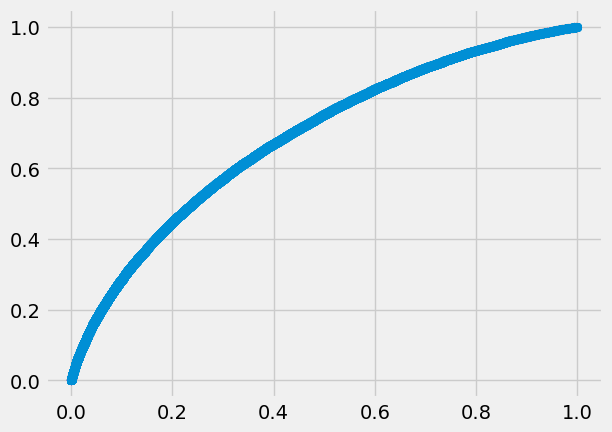

In [174]:
plt.scatter(fpr, tpr)
plt.show()

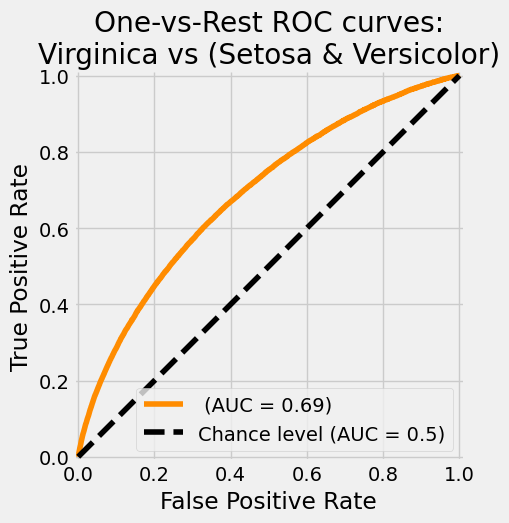

In [175]:
from sklearn.metrics import RocCurveDisplay

display = RocCurveDisplay.from_predictions(
    train_labels,
    submit["TARGET"],
    name=f"",
    curve_kwargs=dict(color="darkorange"),
    plot_chance_level=True,
    despine=True,
)
_ = display.ax_.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="One-vs-Rest ROC curves:\nVirginica vs (Setosa & Versicolor)",
)

C:\Users\SUZON\AppData\Local\Temp\ipykernel_10628\2278950790.py:1: RuntimeWarning: invalid value encountered in divide
  plt.plot(thresholds, (tpr/fpr))


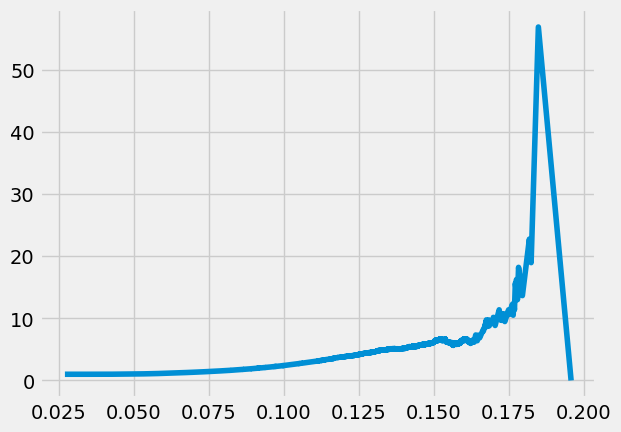

In [176]:
plt.plot(thresholds, (tpr/fpr))
plt.show()

C:\Users\SUZON\AppData\Local\Temp\ipykernel_10628\2420324163.py:1: RuntimeWarning: divide by zero encountered in divide
  plt.plot(thresholds, (fpr/tpr))
C:\Users\SUZON\AppData\Local\Temp\ipykernel_10628\2420324163.py:1: RuntimeWarning: invalid value encountered in divide
  plt.plot(thresholds, (fpr/tpr))


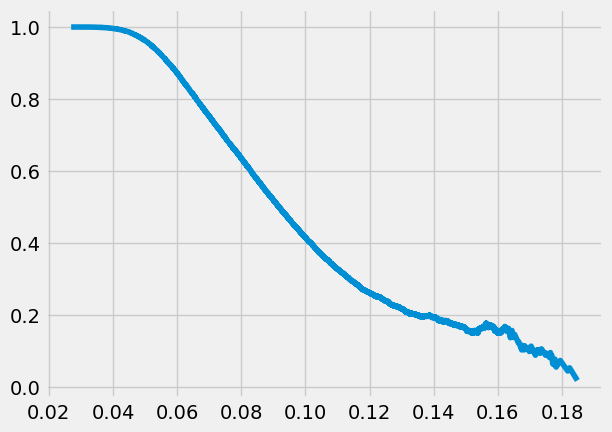

In [177]:
plt.plot(thresholds, (fpr/tpr))
plt.show()

In [178]:
test = tpr/fpr

C:\Users\SUZON\AppData\Local\Temp\ipykernel_10628\486177983.py:1: RuntimeWarning: invalid value encountered in divide
  test = tpr/fpr


In [179]:
test.min()

np.float64(nan)

In [180]:
test = test[~np.isnan(test)]

In [181]:
test.max()

np.float64(56.93454179254783)

In [182]:
thresholds = pd.Series(thresholds, name="seuil")

In [183]:
test = pd.Series(test, name="rapport")

In [ ]:
temp = pd.DataFrame([thresholds, test], index=test.index)

In [ ]:
temp

In [ ]:
temp.pivot(index=temp.columns, columns=temp.index)

In [ ]:
test

In [ ]:
fpr, tpr, thresholds = roc_curve(train_labels, submit["TARGET"])

In [ ]:
submit["TARGET"].describe()

In [ ]:
fpr = np.flip(fpr)

In [ ]:
temp = pd.DataFrame.from_dict({"Seuil" : thresholds, "taux_faux_positif" : fpr, "taux_true_positif" : tpr})

In [ ]:
temp["tfp/ttp"] = temp["taux_faux_positif"]/temp["taux_true_positif"]
temp["ttp/tfp"] = temp["taux_true_positif"]/temp["taux_faux_positif"]

In [ ]:
temp

In [ ]:
plt.plot(temp["Seuil"], temp["tfp/ttp"])

In [ ]:
plt.plot(temp["Seuil"], temp["ttp/tfp"])

In [ ]:
plt.plot(temp["taux_true_positif"], temp["taux_faux_positif"])

In [ ]:
temp["score"] = 1*temp["taux_true_positif"] + 10*temp["taux_faux_positif"]

In [ ]:
plt.plot(temp["Seuil"], temp["score"])

In [ ]:
temp["score"].max()

In [ ]:
temp.loc[temp["score"] == 1]

## Scorer